# World Cup 2026 Complete Winner Prediction Pipeline

This notebook is the clean final modeling workflow for the World Cup 2026 winner prediction project.

It uses the latest improved datasets, including historical team features, SPI features, validated betting odds, head-to-head features, streak features and 2026 schedule odds where available.

Main goals:

1. Load and validate all current datasets.
2. Run EDA and missingness checks before modeling.
3. Prevent leakage from scores, results and future-only information.
4. Build stable feature sets.
5. Train baseline models, the best stacked Logistic Regression model and optional XGBoost/CatBoost challengers.
6. Predict only the winner outcome for 2026 group-stage matches.

Important: predictions are probabilistic estimates, not guarantees.

## 1. Load Libraries And Project Paths

In [239]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, HuberRegressor
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

PROJECT_DIR = Path("/Users/raresolteanu/Desktop/WC-2026")
DATA_DIR = PROJECT_DIR / "datasets"
os.chdir(PROJECT_DIR)

print("Working directory:", Path.cwd())
print("Datasets folder exists:", DATA_DIR.exists())

Working directory: /Users/raresolteanu/Desktop/WC-2026
Datasets folder exists: True


In [240]:

BEST_STACK_CLASS_WEIGHT   = {"away_win": 1, "draw": 2.5, "home_win": 1}
BEST_FULL_CLASS_WEIGHT    = {"away_win": 1, "draw": 2.5, "home_win": 1}
BEST_ODDS_CLASS_WEIGHT    = {"away_win": 1, "draw": 2.5, "home_win": 1}
BEST_RECENCY_DECAY        = 0.0003   # exponential recency weight for LR
BEST_XGB_BOOST            = False    # do NOT boost draw prob for XGBoost
BEST_NN_BOOST             = False    # do NOT boost draw prob for NN
BEST_ENSEMBLE_WEIGHTS     = (0.20, 0.45, 0.20, 0.15)  # stack, cat, xgb, nn

best_weight = BEST_STACK_CLASS_WEIGHT

print("Locked configs loaded ✓")

Locked configs loaded ✓


In [241]:
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception as e:
    HAS_XGBOOST = False
    print("XGBoost unavailable:", e)

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except Exception as e:
    HAS_CATBOOST = False
    print("CatBoost unavailable:", e)

print("HAS_XGBOOST:", HAS_XGBOOST)
print("HAS_CATBOOST:", HAS_CATBOOST)

HAS_XGBOOST: True
HAS_CATBOOST: True


## 2. Load Current Datasets

These are the main files used in this final pipeline:

- `wc_2026_training_table_clean_with_spi_and_odds.csv`: full historical training table with cleaned match features.
- `international_football_odds_validated_best_match.csv`: validated one-row-per-match odds data.
- `WC 2026 match schedule advanced.csv`: 2026 schedule with model features and future odds where available.
- `wc_2026_odds_experiment_model_table.csv`: odds-only historical experiment table, used as a backup/reference.

In [242]:
FULL_PATH = DATA_DIR / "wc_2026_training_table_clean_with_spi_and_odds.csv"
SCHEDULE_PATH = DATA_DIR / "WC 2026 match schedule advanced.csv"
VALIDATED_ODDS_PATH = DATA_DIR / "international_football_odds_validated_best_match.csv"
ODDS_EXPERIMENT_PATH = DATA_DIR / "wc_2026_odds_experiment_model_table.csv"

for path in [FULL_PATH, SCHEDULE_PATH, VALIDATED_ODDS_PATH, ODDS_EXPERIMENT_PATH]:
    print(path.name, "exists:", path.exists())

full_df = pd.read_csv(FULL_PATH)
schedule_2026 = pd.read_csv(SCHEDULE_PATH)
validated_odds = pd.read_csv(VALIDATED_ODDS_PATH)
odds_df_existing = pd.read_csv(ODDS_EXPERIMENT_PATH)

for df in [full_df, schedule_2026, validated_odds, odds_df_existing]:
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("full_df:", full_df.shape)
print("schedule_2026:", schedule_2026.shape)
print("validated_odds:", validated_odds.shape)
print("odds_df_existing:", odds_df_existing.shape)

def boost_draw_prob(probs, boost=1.8):
    """Boost draw class prob before threshold logic. Only use for models
    that systematically underpredict draws (XGBoost DART, Team Embedding NN)."""
    probs = probs.copy()
    probs[:, 1] *= boost  
    probs = probs / probs.sum(axis=1, keepdims=True)
    return probs

def engineer_draw_features(df, history_df=None):
    import numpy as np
    calc_df = df.copy()
    if history_df is not None:
        combined = pd.concat([history_df, calc_df], ignore_index=True)
    else:
        combined = calc_df
        
    combined = combined.sort_values("date").reset_index(drop=True)
    
    combined["home_gd"] = combined["home_score"] - combined["away_score"]
    combined["away_gd"] = combined["away_score"] - combined["home_score"]
    combined["is_draw"] = (combined["result"] == "draw").astype(int)
    
    combined["head_to_head_draw_rate"] = np.where(
        combined["h2h_matches_played"] > 0,
        combined["h2h_draws"] / combined["h2h_matches_played"],
        0.23
    )
    
    combined["is_world_cup"] = combined["tournament"].apply(lambda t: 1 if str(t) == "FIFA World Cup" else 0)
    
    if "fifa_rank_diff" in combined.columns:
        combined["ranking_gap"] = combined["fifa_rank_diff"].abs()
    else:
        combined["ranking_gap"] = 0.0
        
    combined["home_days_rest"] = combined["home_rest_days_capped"].fillna(4.0)
    combined["away_days_rest"] = combined["away_rest_days_capped"].fillna(4.0)
    
    combined["is_neutral_venue"] = combined["neutral"].fillna(0).astype(int)
    
    combined["year"] = combined["date"].dt.year
    team_tournament_counts = {}
    group_stage_match_day_list = []
    
    for idx, row in combined.iterrows():
        h = row["home_team"]
        a = row["away_team"]
        t = row["tournament"]
        y = row["year"]
        
        key_h = (h, t, y)
        key_a = (a, t, y)
        
        count_h = team_tournament_counts.get(key_h, 0)
        count_a = team_tournament_counts.get(key_a, 0)
        
        mday = max(count_h, count_a) + 1
        group_stage_match_day_list.append(min(mday, 3))
        
        team_tournament_counts[key_h] = count_h + 1
        team_tournament_counts[key_a] = count_a + 1
        
    combined["group_stage_match_day"] = group_stage_match_day_list
    
    team_history = {}
    for idx, row in combined.iterrows():
        h = row["home_team"]
        a = row["away_team"]
        if h not in team_history:
            team_history[h] = []
        if a not in team_history:
            team_history[a] = []
            
    recent_draw_rate_home_list = []
    recent_draw_rate_away_list = []
    goal_diff_last5_list = []
    
    for idx, row in combined.iterrows():
        h = row["home_team"]
        a = row["away_team"]
        dt = row["date"]
        
        h_home_games = [g for g in team_history[h] if g["was_home"]][-5:]
        draw_rate_h = np.mean([g["is_draw"] for g in h_home_games]) if len(h_home_games) > 0 else 0.23
            
        a_away_games = [g for g in team_history[a] if not g["was_home"]][-5:]
        draw_rate_a = np.mean([g["is_draw"] for g in a_away_games]) if len(a_away_games) > 0 else 0.23
            
        h_all_games = team_history[h][-5:]
        a_all_games = team_history[a][-5:]
        
        h_gd_mean = np.mean([g["gd"] for g in h_all_games]) if len(h_all_games) > 0 else 0.0
        a_gd_mean = np.mean([g["gd"] for g in a_all_games]) if len(a_all_games) > 0 else 0.0
        
        recent_draw_rate_home_list.append(draw_rate_h)
        recent_draw_rate_away_list.append(draw_rate_a)
        goal_diff_last5_list.append(h_gd_mean - a_gd_mean)
        
        gd_h = row["home_gd"] if not pd.isna(row["home_gd"]) else 0.0
        gd_a = row["away_gd"] if not pd.isna(row["away_gd"]) else 0.0
        is_dr = row["is_draw"] if not pd.isna(row["is_draw"]) else 0
        
        team_history[h].append({"date": dt, "was_home": True, "gd": gd_h, "is_draw": is_dr})
        team_history[a].append({"date": dt, "was_home": False, "gd": gd_a, "is_draw": is_dr})

    combined["recent_draw_rate_home"] = recent_draw_rate_home_list
    combined["recent_draw_rate_away"] = recent_draw_rate_away_list
    combined["goal_diff_last5"] = goal_diff_last5_list
    
    if "stage" in combined.columns:
        combined["tournament_stage"] = combined["stage"].apply(lambda s: 1 if s in ["Group Stage", "Not World Cup"] else 0)
    else:
        combined["tournament_stage"] = combined["group"].apply(lambda g: 1 if str(g) in ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L"] else 0)
        
    if history_df is not None:
        return combined.iloc[len(history_df):].copy()
    else:
        return combined

full_df = engineer_draw_features(full_df)
schedule_2026 = engineer_draw_features(schedule_2026, history_df=full_df)
schedule2026 = schedule_2026


wc_2026_training_table_clean_with_spi_and_odds.csv exists: True
WC 2026 match schedule advanced.csv exists: True
international_football_odds_validated_best_match.csv exists: True
wc_2026_odds_experiment_model_table.csv exists: True


full_df: (30696, 140)
schedule_2026: (104, 75)
validated_odds: (1184, 41)
odds_df_existing: (1080, 140)


## 3. Feature Definitions

The final model uses several groups of features:

- **Baseline team-strength features**: Elo, FIFA ranking, recent form, attack/defense, rest and host-region indicators.
- **H2H and streak features**: chronological head-to-head and team streak signals.
- **Advanced pre-match features**: strength/xG/injury fields where available.
- **Market value features**: squad and top-player market-value differences, when files exist.
- **Odds features**: normalized betting market probabilities.
- **SPI features**: SPI probabilities/projected scores, when available.

Scores and match results are never included as model features.

In [243]:
CLASS_ORDER = ["away_win", "draw", "home_win"]

baseline_features = [
    "elo_diff",
    "fifa_rank_diff",
    "fifa_points_zscore_diff",
    "form_score_5_diff",
    "form_score_10_diff",
    "form_trend_diff",
    "attack_diff",
    "defense_diff",
    "rest_days_diff",
    "neutral",
    "is_home_country",
    "is_home_confed",
    "is_away_confed",
    "missing_fifa_rank",
    "missing_fifa_points_zscore",
    "recent_draw_rate_home",
    "recent_draw_rate_away",
    "goal_diff_last5",
    "tournament_stage",
    "is_world_cup",
    "ranking_gap",
    "home_days_rest",
    "away_days_rest",
    "is_neutral_venue",
    "group_stage_match_day",
    "head_to_head_draw_rate",
]

h2h_streak_features = [
    "h2h_matches_played",
    "h2h_wins_diff",
    "h2h_draws",
    "h2h_goals_diff",
    "h2h_avg_goals_diff",
    "home_win_streak",
    "home_unbeaten_streak",
    "away_win_streak",
    "away_unbeaten_streak",
    "win_streak_diff",
    "unbeaten_streak_diff",
]

advanced_features = [
    "strength_rating_diff",
    "attack_rating_diff",
    "defense_rating_diff",
    "xg_attack_diff",
    "xg_defense_diff",
    "xg_balance_diff",
    "unavailable_diff",
    "missing_player_value_diff",
    "has_injury_data",
]

market_value_features = [
    "squad_value_diff",
    "top_player_value_diff",
]

odds_features = [
    "market_home_prob_norm",
    "market_draw_prob_norm",
    "market_away_prob_norm",
    "odds_prob_diff",
    "market_favorite_prob",
    "market_draw_prob",
]

spi_features = [
    "home_spi_prob",
    "draw_spi_prob",
    "away_spi_prob",
    "spi_prob_diff",
    "home_spi_proj_score",
    "away_spi_proj_score",
    "spi_proj_score_diff",
]

full_features_base = baseline_features + h2h_streak_features + advanced_features + market_value_features
odds_compact_features = ["market_home_prob_norm", "market_draw_prob_norm", "market_away_prob_norm"]
odds_full_features = full_features_base + odds_features
spi_full_features = full_features_base + spi_features
xgb_cat_features = full_features_base + odds_features + spi_features

all_possible_features = sorted(set(full_features_base + odds_features + spi_features + xgb_cat_features))

print("Baseline features:", len(baseline_features))
print("Full base features:", len(full_features_base))
print("Odds full features:", len(odds_full_features))
print("XGB/Cat features:", len(xgb_cat_features))

Baseline features: 26
Full base features: 48
Odds full features: 54
XGB/Cat features: 61


## 4. Add Market Value Features When Available

This uses the squad market values and top-player market values if those files exist. Missing teams are filled by a robust regression fallback based on Elo/strength rating where possible, then median fallback.

In [244]:
SQUAD_VALUE_PATH = DATA_DIR / "wc_2026_squad_market_values.csv"
TOP_PLAYER_VALUE_PATH = DATA_DIR / "wc_2026_top_players_market_values.csv"
TEAM_STRENGTH_PATH = DATA_DIR / "Team strength ratings.csv"


def build_team_market_value_table():
    team_values = pd.DataFrame(columns=["team", "squad_value_eur_m", "top_player_value_eur_m"])

    if SQUAD_VALUE_PATH.exists():
        squad_values = pd.read_csv(SQUAD_VALUE_PATH)
        squad_values = squad_values[["team", "squad_value_eur_m"]].copy()
    else:
        squad_values = pd.DataFrame(columns=["team", "squad_value_eur_m"])

    if TOP_PLAYER_VALUE_PATH.exists():
        top_players = pd.read_csv(TOP_PLAYER_VALUE_PATH)
        top_values = (
            top_players
            .groupby("team", as_index=False)["market_value_eur_m"]
            .max()
            .rename(columns={"market_value_eur_m": "top_player_value_eur_m"})
        )
    else:
        top_values = pd.DataFrame(columns=["team", "top_player_value_eur_m"])

    team_values = squad_values.merge(top_values, on="team", how="outer")

    if TEAM_STRENGTH_PATH.exists():
        strength = pd.read_csv(TEAM_STRENGTH_PATH)
        strength_cols = [c for c in ["team", "elo_rating", "overall_rating", "attack_rating", "defense_rating"] if c in strength.columns]
        team_values = team_values.merge(strength[strength_cols], on="team", how="left")

    for value_col in ["squad_value_eur_m", "top_player_value_eur_m"]:
        if value_col not in team_values.columns:
            team_values[value_col] = np.nan

        if "elo_rating" in team_values.columns:
            known = team_values[value_col].notna() & team_values["elo_rating"].notna()
            missing = team_values[value_col].isna() & team_values["elo_rating"].notna()

            if known.sum() >= 10 and missing.sum() > 0:
                model = HuberRegressor()
                model.fit(team_values.loc[known, ["elo_rating"]], team_values.loc[known, value_col])
                team_values.loc[missing, value_col] = model.predict(team_values.loc[missing, ["elo_rating"]])

        team_values[value_col] = team_values[value_col].fillna(team_values[value_col].median())

    return team_values[["team", "squad_value_eur_m", "top_player_value_eur_m"]].drop_duplicates("team")


team_market_values = build_team_market_value_table()
print(team_market_values.shape)
display(team_market_values.head())


def add_market_value_features(df):
    df = df.copy()

    home_values = team_market_values.rename(columns={
        "team": "home_team",
        "squad_value_eur_m": "home_squad_value_eur_m",
        "top_player_value_eur_m": "home_top_player_value_eur_m",
    })

    away_values = team_market_values.rename(columns={
        "team": "away_team",
        "squad_value_eur_m": "away_squad_value_eur_m",
        "top_player_value_eur_m": "away_top_player_value_eur_m",
    })

    df = df.merge(home_values, on="home_team", how="left")
    df = df.merge(away_values, on="away_team", how="left")

    for col in ["home_squad_value_eur_m", "away_squad_value_eur_m", "home_top_player_value_eur_m", "away_top_player_value_eur_m"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    df["squad_value_diff"] = df["home_squad_value_eur_m"] - df["away_squad_value_eur_m"]
    df["top_player_value_diff"] = df["home_top_player_value_eur_m"] - df["away_top_player_value_eur_m"]

    return df


full_df = add_market_value_features(full_df)
schedule_2026 = add_market_value_features(schedule_2026)
odds_df_existing = add_market_value_features(odds_df_existing)

print(full_df[["squad_value_diff", "top_player_value_diff"]].describe())

(48, 3)


,team,squad_value_eur_m,top_player_value_eur_m
0,Algeria,256.90,35.0
1,Argentina,807.50,110.0
2,Australia,77.45,15.0
3,Austria,245.20,30.0
4,Belgium,547.50,65.0


       squad_value_diff  top_player_value_diff
count      30696.000000           30696.000000
mean          18.620388               2.189650
std          339.945915              51.749453
min        -1520.000000            -200.000000
25%            0.000000               0.000000
50%            0.000000               0.000000
75%           20.150000               3.500000
max         1520.000000             200.000000


## 5. Integrate Validated Odds

This step overlays the validated odds file onto the historical table and 2026 schedule. It does not use match scores as features, scores are only present in the historical odds file to verify alignment.

In [245]:
ODDS_RENAME = {
    "home_odds": "validated_home_win_odds",
    "draw_odds": "validated_draw_odds",
    "away_odds": "validated_away_win_odds",
    "home_implied_prob": "validated_home_implied_prob",
    "draw_implied_prob": "validated_draw_implied_prob",
    "away_implied_prob": "validated_away_implied_prob",
    "market_home_prob_norm": "validated_market_home_prob_norm",
    "market_draw_prob_norm": "validated_market_draw_prob_norm",
    "market_away_prob_norm": "validated_market_away_prob_norm",
    "odds_prob_diff": "validated_odds_prob_diff",
    "market_draw_prob": "validated_market_draw_prob",
    "market_favorite": "validated_market_favorite",
    "market_favorite_prob": "validated_market_favorite_prob",
    "has_market_odds": "validated_has_market_odds",
    "source_id": "validated_odds_source_id",
}


def integrate_validated_odds(target_df, odds_df):
    target_df = target_df.copy()
    original_rows = len(target_df)

    odds_cols = ["date", "home_team", "away_team"] + [c for c in ODDS_RENAME if c in odds_df.columns]
    odds_small = odds_df[odds_cols].rename(columns=ODDS_RENAME).copy()
    odds_small = odds_small.drop_duplicates(["date", "home_team", "away_team"])

    out = target_df.merge(odds_small, on=["date", "home_team", "away_team"], how="left")

    if len(out) != original_rows:
        raise ValueError("Odds merge changed row count. Check duplicate keys.")

    update_pairs = {
        "home_win_odds": "validated_home_win_odds",
        "draw_odds": "validated_draw_odds",
        "away_win_odds": "validated_away_win_odds",
        "home_implied_prob": "validated_home_implied_prob",
        "draw_implied_prob": "validated_draw_implied_prob",
        "away_implied_prob": "validated_away_implied_prob",
        "market_home_prob_norm": "validated_market_home_prob_norm",
        "market_draw_prob_norm": "validated_market_draw_prob_norm",
        "market_away_prob_norm": "validated_market_away_prob_norm",
        "odds_prob_diff": "validated_odds_prob_diff",
        "market_draw_prob": "validated_market_draw_prob",
        "market_favorite": "validated_market_favorite",
        "market_favorite_prob": "validated_market_favorite_prob",
        "has_market_odds": "validated_has_market_odds",
    }

    for base_col, validated_col in update_pairs.items():
        if validated_col not in out.columns:
            continue
        if base_col not in out.columns:
            out[base_col] = np.nan
        mask = out[validated_col].notna()
        out.loc[mask, base_col] = out.loc[mask, validated_col]

    if "validated_odds_source_id" in out.columns:
        out["odds_source_id"] = out.get("odds_source_id", pd.Series(index=out.index, dtype=object))
        mask = out["validated_odds_source_id"].notna()
        out.loc[mask, "odds_source_id"] = out.loc[mask, "validated_odds_source_id"]

    out["has_market_odds"] = pd.to_numeric(out.get("has_market_odds", 0), errors="coerce").fillna(0).astype(int)

    drop_cols = [c for c in out.columns if c.startswith("validated_")]
    out = out.drop(columns=drop_cols)

    return out


full_df = integrate_validated_odds(full_df, validated_odds)
schedule_2026 = integrate_validated_odds(schedule_2026, validated_odds)

print("Historical rows with odds:", int(full_df["has_market_odds"].sum()))
print("Schedule rows with odds:", int(schedule_2026["has_market_odds"].sum()))

display(
    full_df.loc[full_df["has_market_odds"].eq(1), [
        "date", "home_team", "away_team", "result",
        "home_win_odds", "draw_odds", "away_win_odds",
        "market_home_prob_norm", "market_draw_prob_norm", "market_away_prob_norm",
        "odds_source_id",
    ]].head()
)

Historical rows with odds: 1080
Schedule rows with odds: 104


,date,home_team,away_team,result,home_win_odds,draw_odds,away_win_odds,market_home_prob_norm,market_draw_prob_norm,market_away_prob_norm,odds_source_id
19153,2014-06-12,Brazil,Croatia,home_win,1.31,5.11,12.02,0.732416,0.187762,0.079822,oddsportal:average
19154,2014-06-13,Chile,Australia,home_win,1.42,4.40,8.63,0.672373,0.216993,0.110634,oddsportal:average
19155,2014-06-13,Mexico,Cameroon,home_win,2.18,3.14,3.74,0.439144,0.304884,0.255972,oddsportal:average
19156,2014-06-13,Spain,Netherlands,away_win,1.84,3.32,4.99,0.520033,0.288211,0.191756,oddsportal:average
19157,2014-06-14,Colombia,Greece,home_win,1.84,3.26,5.12,0.519807,0.293388,0.186806,oddsportal:average


## 6. Data Quality Checks

In [246]:
MATCH_KEY = ["date", "home_team", "away_team"]


def duplicate_key_count(df, name):
    count = df.duplicated(MATCH_KEY).sum()
    print(f"{name} duplicate match keys: {count}")
    return count


def target_balance(df, name):
    out = (
        df["result"]
        .value_counts()
        .rename_axis("result")
        .reset_index(name="count")
    )
    out["share"] = (out["count"] / len(df)).round(4)
    out["dataset"] = name
    return out


def rows_by_year(df, name):
    temp = df.copy()
    temp["year"] = temp["date"].dt.year
    out = temp.groupby("year").size().reset_index(name="rows")
    out["dataset"] = name
    return out


def missing_summary(df, name, top_n=25):
    out = (
        df.isna().sum()
        .sort_values(ascending=False)
        .reset_index()
    )
    out.columns = ["column", "missing_rows"]
    out["missing_share"] = (out["missing_rows"] / len(df)).round(4)
    out["dataset"] = name
    return out[out["missing_rows"] > 0].head(top_n)


duplicate_key_count(full_df, "full_df")
duplicate_key_count(schedule_2026, "schedule_2026")
duplicate_key_count(validated_odds, "validated_odds")

trainable_preview = full_df[full_df["result"].notna()].copy()
display(target_balance(trainable_preview, "full_df_result_rows"))
display(rows_by_year(full_df, "full_df").tail(15))
display(missing_summary(full_df, "full_df"))
display(missing_summary(schedule_2026, "schedule_2026"))

full_df duplicate match keys: 0
schedule_2026 duplicate match keys: 0
validated_odds duplicate match keys: 0


,result,count,share,dataset
0,home_win,14905,0.4856,full_df_result_rows
1,away_win,8634,0.2813,full_df_result_rows
2,draw,7157,0.2332,full_df_result_rows


,year,rows,dataset
19,2012,1025,full_df
20,2013,963,full_df
21,2014,856,full_df
22,2015,1039,full_df
23,2016,920,full_df
24,2017,924,full_df
25,2018,929,full_df
26,2019,1149,full_df
27,2020,347,full_df
28,2021,1115,full_df


,column,missing_rows,missing_share,dataset
0,odds_source_id,29616,0.9648,full_df
1,away_spi_importance,3844,0.1252,full_df
2,spi_importance_diff,3844,0.1252,full_df
3,home_spi_importance,3844,0.1252,full_df
4,ranking_gap,2683,0.0874,full_df
5,fifa_rank_diff,2683,0.0874,full_df
6,fifa_points_zscore_diff,2683,0.0874,full_df
7,is_partial_fifa_ranking_date_y,2156,0.0702,full_df
8,is_fifa_zscore_outlier_y,2156,0.0702,full_df
9,teams_in_ranking_date_y,2156,0.0702,full_df


,column,missing_rows,missing_share,dataset
0,away_has_enough_goal_history,104,1.0,schedule_2026
1,away_has_any_form_10,104,1.0,schedule_2026
2,away_cumulative_matches,104,1.0,schedule_2026
3,home_has_enough_goal_history,104,1.0,schedule_2026
4,home_avg_goals_conceded,104,1.0,schedule_2026
5,home_avg_goals_scored,104,1.0,schedule_2026
6,home_cumulative_matches,104,1.0,schedule_2026
7,away_form_trend,104,1.0,schedule_2026
8,home_form_trend,104,1.0,schedule_2026
9,away_has_full_form_10,104,1.0,schedule_2026


In [247]:
def check_market_probs(df, name):
    prob_cols = ["market_home_prob_norm", "market_draw_prob_norm", "market_away_prob_norm"]
    if not all(c in df.columns for c in prob_cols):
        print(name, "missing market probability columns")
        return

    temp = df[df.get("has_market_odds", 0).eq(1)].copy()
    if temp.empty:
        print(name, "has no market odds rows")
        return

    temp["market_prob_sum"] = temp[prob_cols].sum(axis=1)
    print("\n", name)
    display(temp["market_prob_sum"].describe())
    bad = temp[~temp["market_prob_sum"].between(0.99, 1.01)]
    print("Bad probability rows:", len(bad))

check_market_probs(full_df, "full_df")
check_market_probs(schedule_2026, "schedule_2026")
check_market_probs(validated_odds, "validated_odds")


 full_df


count    1.080000e+03
mean     1.000000e+00
std      1.247807e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: market_prob_sum, dtype: float64

Bad probability rows: 0

 schedule_2026


count    1.040000e+02
mean     1.000000e+00
std      9.723109e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: market_prob_sum, dtype: float64

Bad probability rows: 0

 validated_odds


count    1.184000e+03
mean     1.000000e+00
std      1.225746e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: market_prob_sum, dtype: float64

Bad probability rows: 0


## 7. EDA Helpers

These plots help catch strange distributions, biased features, missing markets, and feature relationships before training.

In [248]:
def plot_hist(df, col, title=None, bins=30):
    if col not in df.columns:
        print(f"Missing column: {col}")
        return
    data = pd.to_numeric(df[col], errors="coerce").dropna()
    if data.empty:
        print(f"No numeric data for {col}")
        return
    plt.figure(figsize=(8, 4.5))
    plt.hist(data, bins=bins, edgecolor="black", alpha=0.85)
    plt.title(title or f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(alpha=0.25)
    plt.show()


def plot_bar_counts(df, col, title=None, top_n=None, normalize=False):
    if col not in df.columns:
        print(f"Missing column: {col}")
        return
    counts = df[col].value_counts(normalize=normalize).head(top_n)
    plt.figure(figsize=(9, 4.5))
    counts.sort_values().plot(kind="barh")
    plt.title(title or f"Counts of {col}")
    plt.xlabel("Share" if normalize else "Count")
    plt.ylabel(col)
    plt.grid(axis="x", alpha=0.25)
    plt.show()


def plot_scatter(df, x, y, title=None, alpha=0.35):
    if x not in df.columns or y not in df.columns:
        print(f"Missing columns: {x}, {y}")
        return
    temp = df[[x, y]].apply(pd.to_numeric, errors="coerce").dropna()
    plt.figure(figsize=(7, 5))
    plt.scatter(temp[x], temp[y], alpha=alpha)
    plt.title(title or f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.grid(alpha=0.25)
    plt.show()


def plot_corr_heatmap(df, cols, title):
    existing = [c for c in cols if c in df.columns]
    if len(existing) < 2:
        print("Not enough columns for heatmap")
        return
    corr = df[existing].apply(pd.to_numeric, errors="coerce").corr()
    plt.figure(figsize=(10, 8))
    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(label="Correlation")
    plt.xticks(range(len(existing)), existing, rotation=90)
    plt.yticks(range(len(existing)), existing)
    plt.title(title)
    for i in range(len(existing)):
        for j in range(len(existing)):
            plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


def result_rate_by_bins(df, feature, bins=5, plot=True):
    if feature not in df.columns:
        print(f"Missing feature: {feature}")
        return pd.DataFrame()
    temp = df[[feature, "result"]].dropna().copy()
    temp[feature] = pd.to_numeric(temp[feature], errors="coerce")
    temp = temp.dropna()
    temp["bin"] = pd.qcut(temp[feature], q=bins, duplicates="drop")
    rates = (
        temp.groupby("bin", observed=False)["result"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .reindex(columns=CLASS_ORDER, fill_value=0)
        .round(3)
    )
    if plot:
        rates.plot(kind="bar", figsize=(9, 4.5))
        plt.title(f"Result Share by {feature} Bin")
        plt.xlabel(feature)
        plt.ylabel("Result share")
        plt.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()
    display(rates)
    return rates

## 8. EDA: Historical, Odds, SPI, And Schedule Features

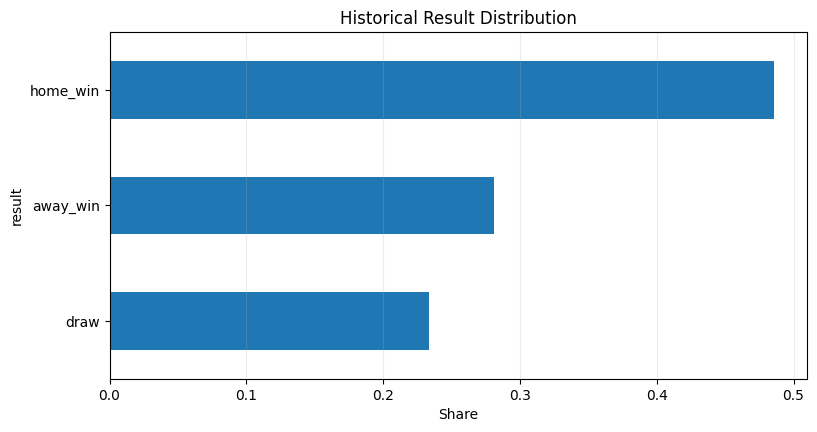

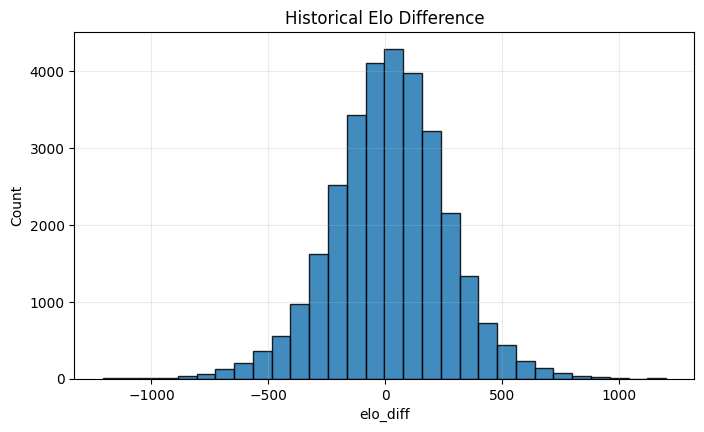

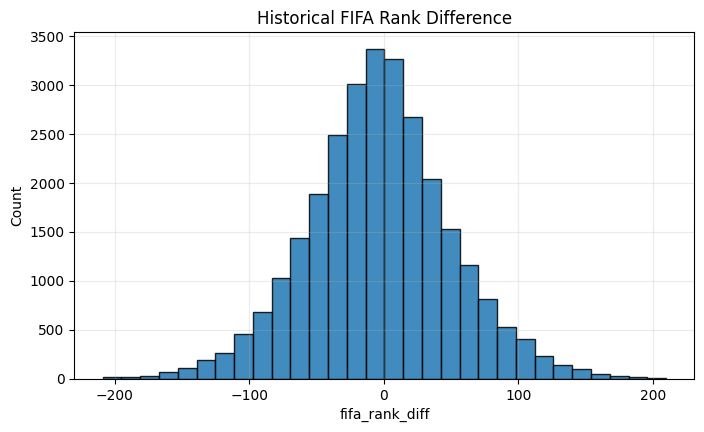

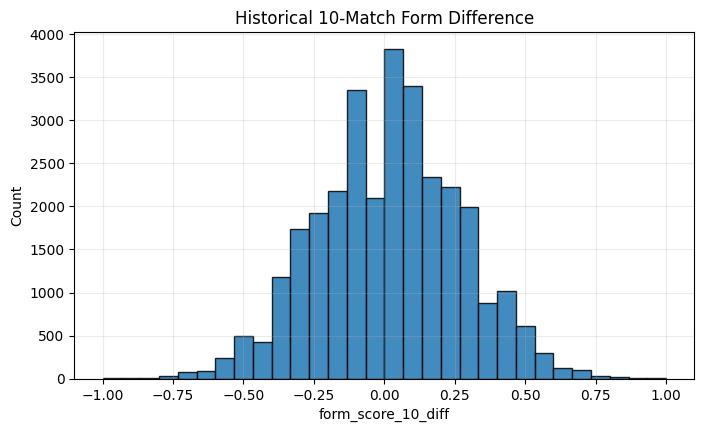

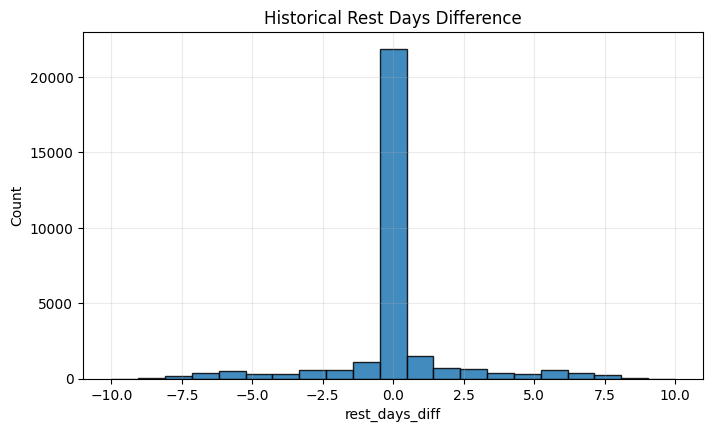

In [249]:
plot_bar_counts(full_df[full_df["result"].notna()], "result", "Historical Result Distribution", normalize=True)
plot_hist(full_df, "elo_diff", "Historical Elo Difference")
plot_hist(full_df, "fifa_rank_diff", "Historical FIFA Rank Difference")
plot_hist(full_df, "form_score_10_diff", "Historical 10-Match Form Difference")
plot_hist(full_df, "rest_days_diff", "Historical Rest Days Difference", bins=21)

Historical rows with odds: 1080


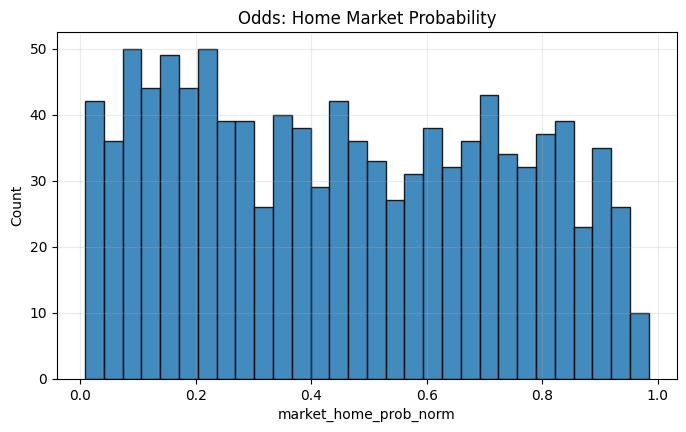

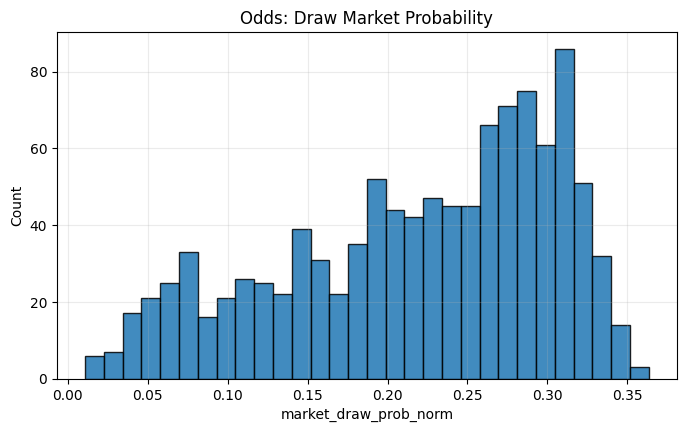

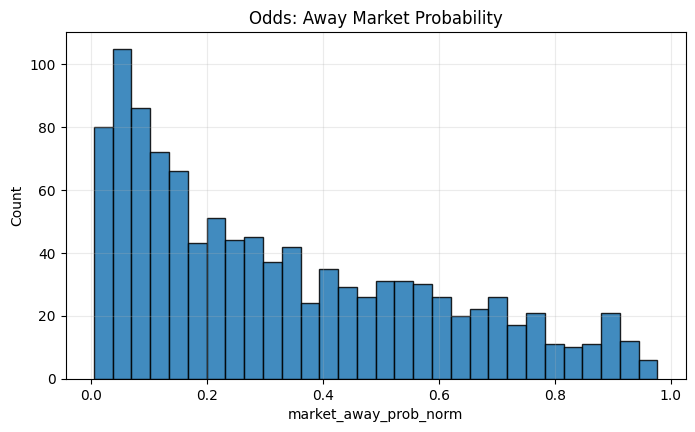

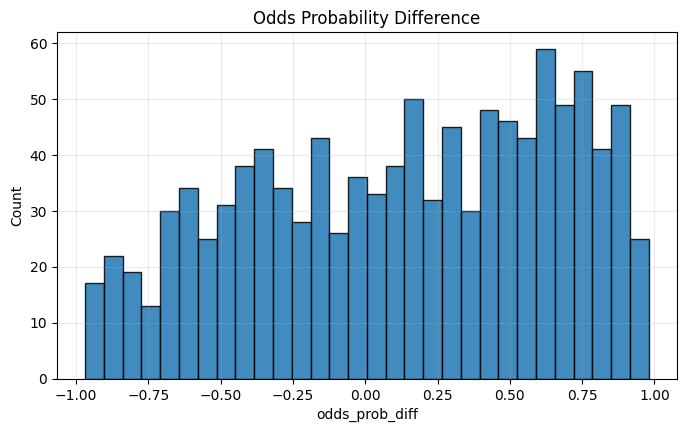

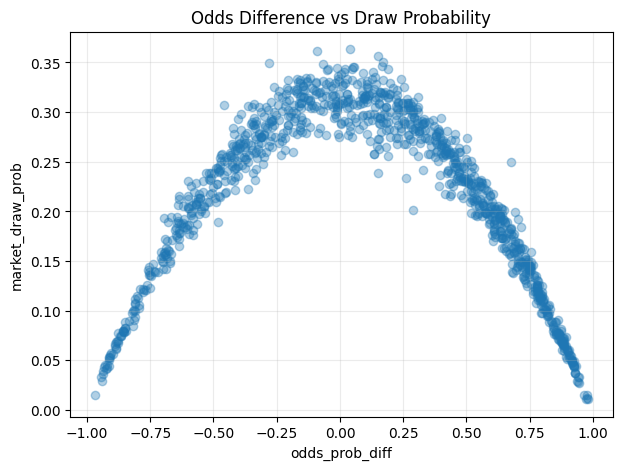

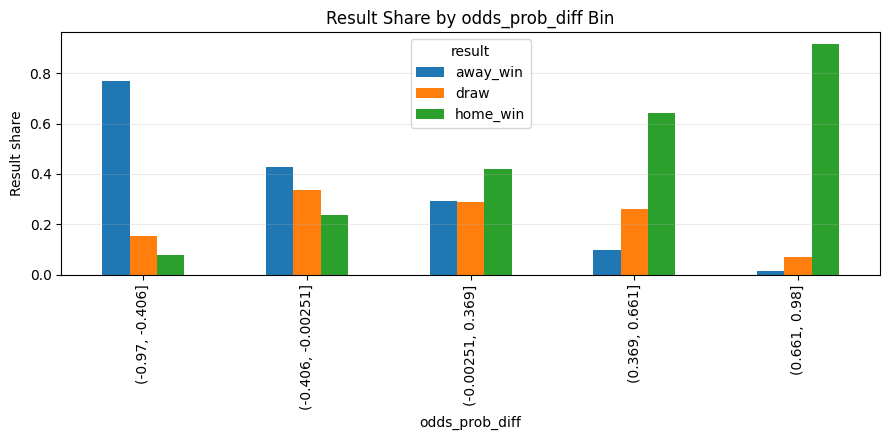

result,away_win,draw,home_win
bin,,,
"(-0.97, -0.406]",0.769,0.153,0.079
"(-0.406, -0.00251]",0.426,0.338,0.236
"(-0.00251, 0.369]",0.292,0.287,0.421
"(0.369, 0.661]",0.097,0.259,0.644
"(0.661, 0.98]",0.014,0.069,0.917


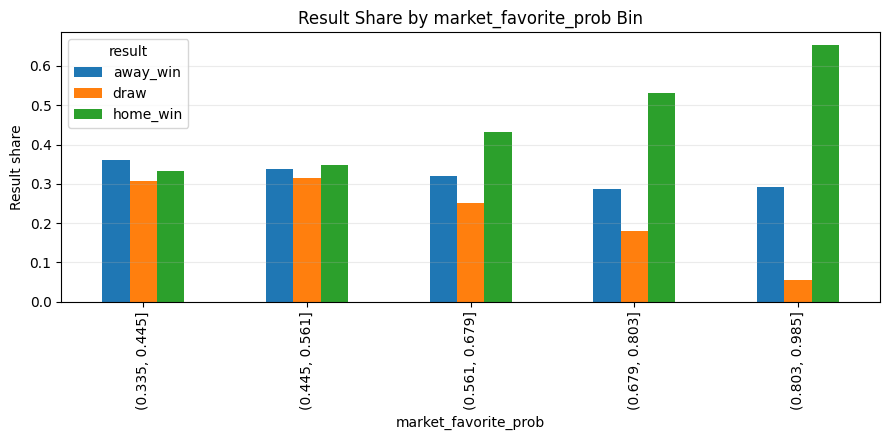

result,away_win,draw,home_win
bin,,,
"(0.335, 0.445]",0.361,0.306,0.333
"(0.445, 0.561]",0.338,0.315,0.347
"(0.561, 0.679]",0.319,0.250,0.431
"(0.679, 0.803]",0.287,0.181,0.532
"(0.803, 0.985]",0.292,0.056,0.653


result,away_win,draw,home_win
bin,,,
"(0.335, 0.445]",0.361,0.306,0.333
"(0.445, 0.561]",0.338,0.315,0.347
"(0.561, 0.679]",0.319,0.250,0.431
"(0.679, 0.803]",0.287,0.181,0.532
"(0.803, 0.985]",0.292,0.056,0.653


In [250]:
odds_rows = full_df[full_df.get("has_market_odds", 0).eq(1)].copy()
print("Historical rows with odds:", len(odds_rows))

plot_hist(odds_rows, "market_home_prob_norm", "Odds: Home Market Probability")
plot_hist(odds_rows, "market_draw_prob_norm", "Odds: Draw Market Probability")
plot_hist(odds_rows, "market_away_prob_norm", "Odds: Away Market Probability")
plot_hist(odds_rows, "odds_prob_diff", "Odds Probability Difference")
plot_scatter(odds_rows, "odds_prob_diff", "market_draw_prob", "Odds Difference vs Draw Probability")
result_rate_by_bins(odds_rows, "odds_prob_diff")
result_rate_by_bins(odds_rows, "market_favorite_prob")

Rows with SPI probability features: 30696


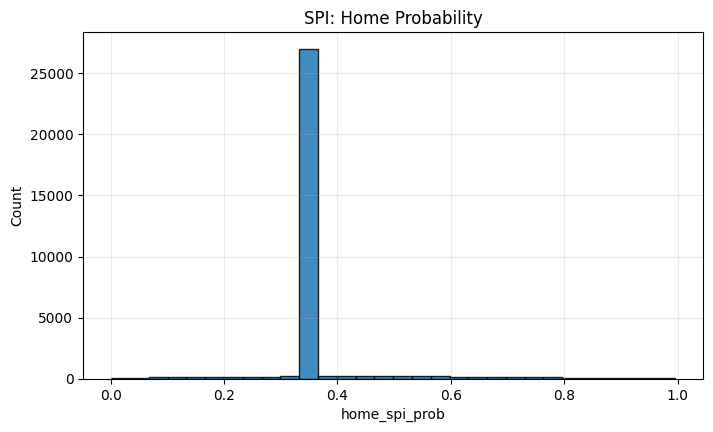

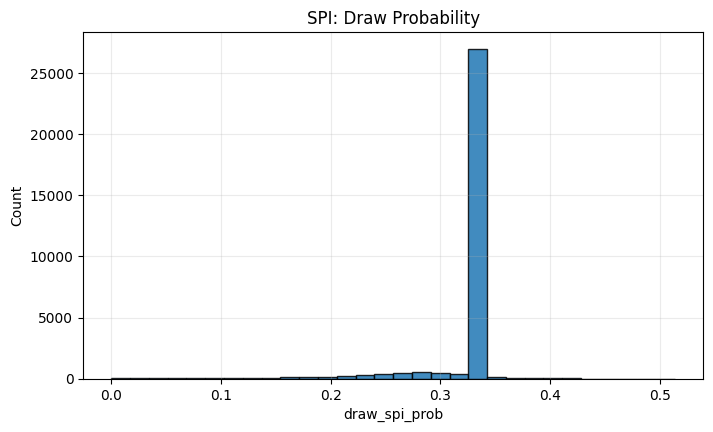

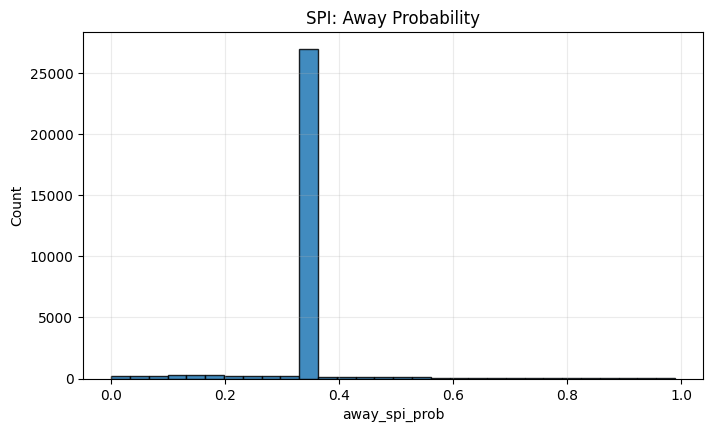

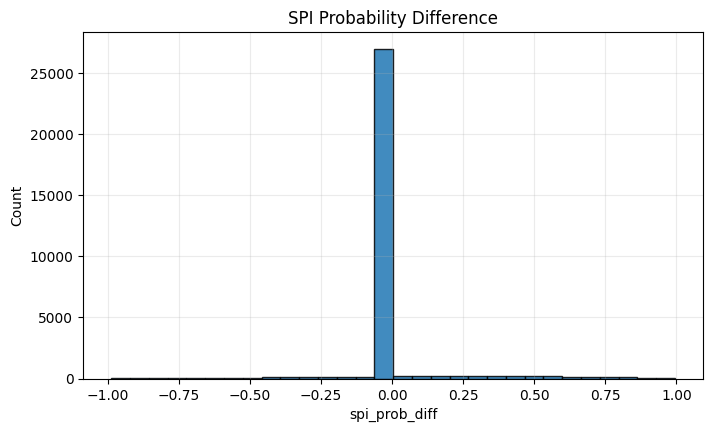

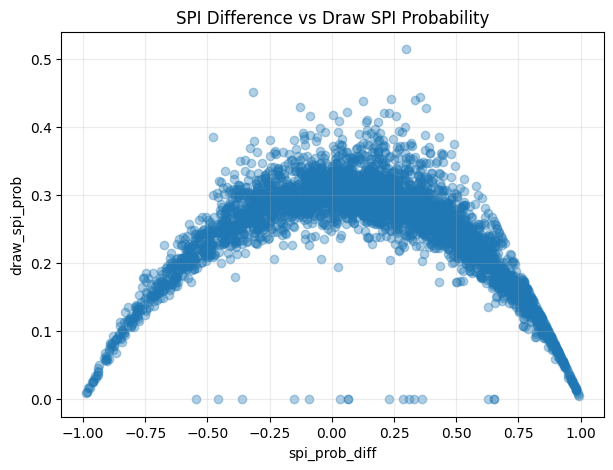

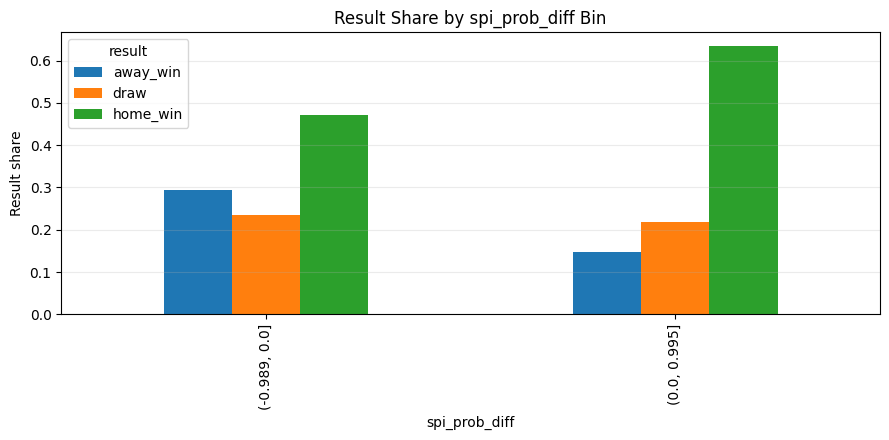

result,away_win,draw,home_win
bin,,,
"(-0.989, 0.0]",0.293,0.235,0.472
"(0.0, 0.995]",0.147,0.218,0.635


result,away_win,draw,home_win
bin,,,
"(-0.989, 0.0]",0.293,0.235,0.472
"(0.0, 0.995]",0.147,0.218,0.635


In [251]:
spi_rows = full_df[[c for c in full_df.columns if c in ["home_spi_prob", "draw_spi_prob", "away_spi_prob", "spi_prob_diff", "result"]]].dropna().copy()
print("Rows with SPI probability features:", len(spi_rows))

plot_hist(full_df, "home_spi_prob", "SPI: Home Probability")
plot_hist(full_df, "draw_spi_prob", "SPI: Draw Probability")
plot_hist(full_df, "away_spi_prob", "SPI: Away Probability")
plot_hist(full_df, "spi_prob_diff", "SPI Probability Difference")
plot_scatter(full_df, "spi_prob_diff", "draw_spi_prob", "SPI Difference vs Draw SPI Probability")
result_rate_by_bins(full_df.dropna(subset=["spi_prob_diff", "result"]), "spi_prob_diff")

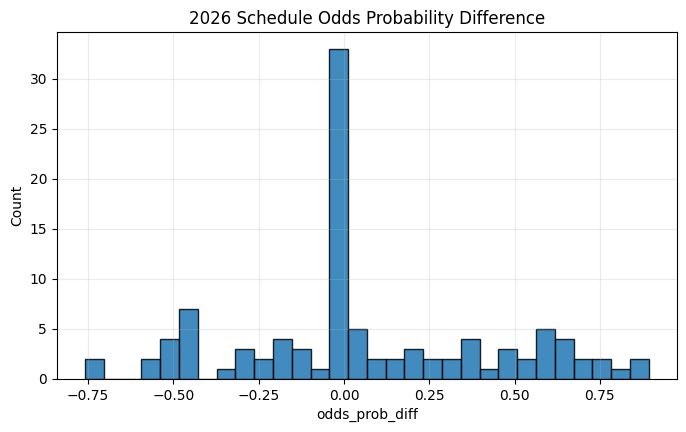

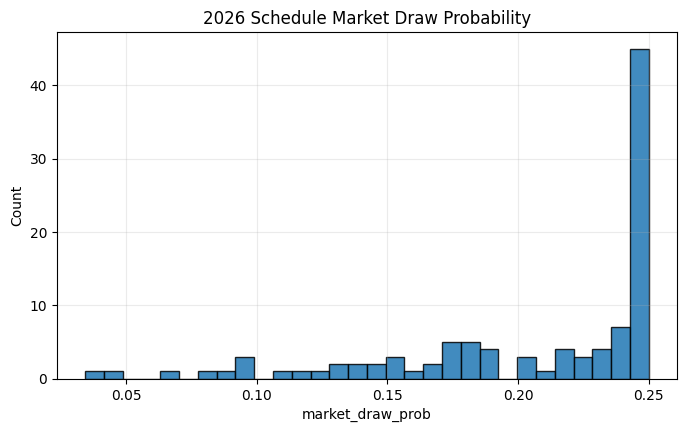

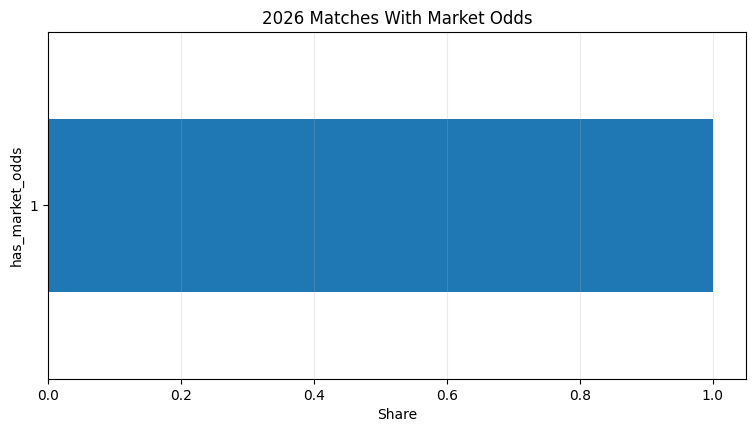

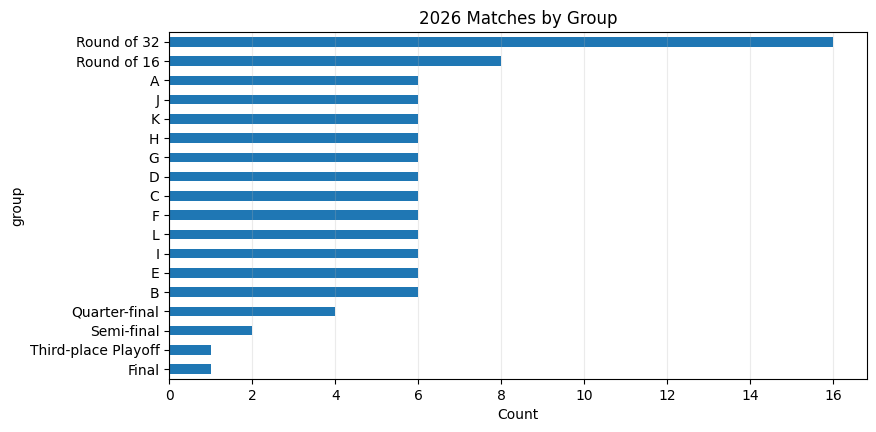

In [252]:
plot_hist(schedule_2026, "odds_prob_diff", "2026 Schedule Odds Probability Difference")
plot_hist(schedule_2026, "market_draw_prob", "2026 Schedule Market Draw Probability")
plot_bar_counts(schedule_2026, "has_market_odds", "2026 Matches With Market Odds", normalize=True)
plot_bar_counts(schedule_2026, "group", "2026 Matches by Group")

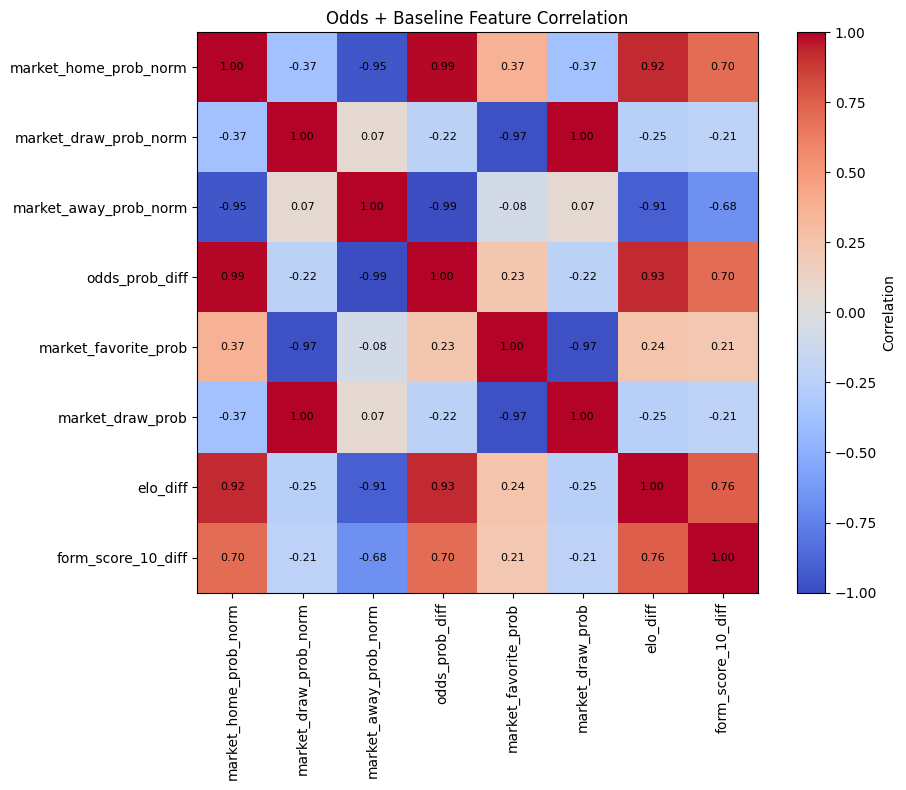

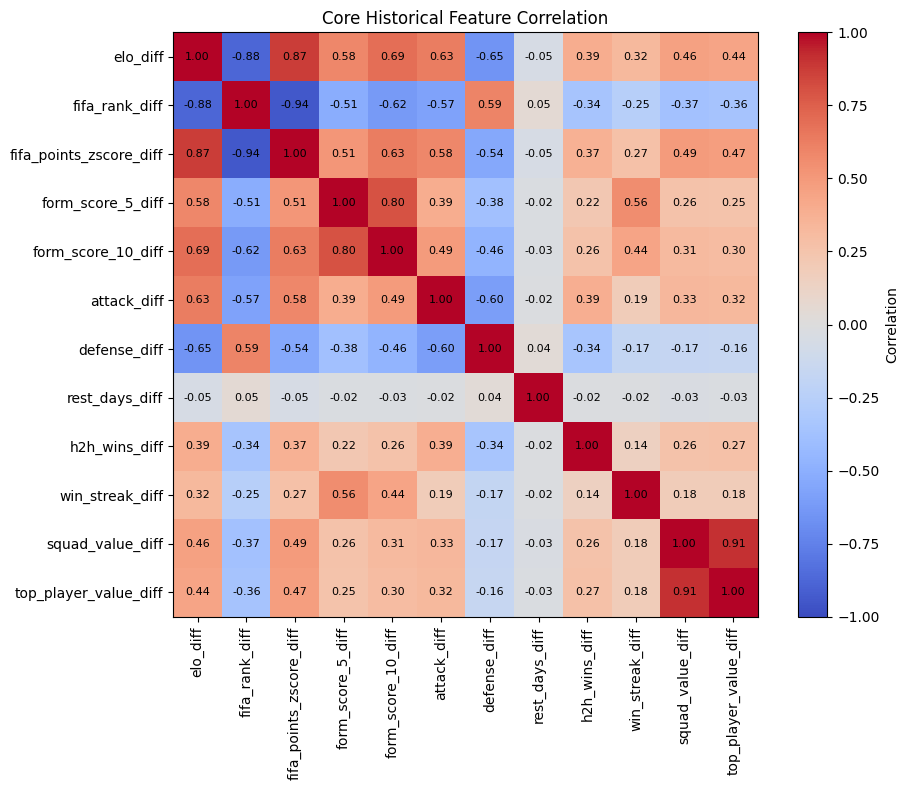

In [253]:
plot_corr_heatmap(
    odds_rows,
    [
        "market_home_prob_norm",
        "market_draw_prob_norm",
        "market_away_prob_norm",
        "odds_prob_diff",
        "market_favorite_prob",
        "market_draw_prob",
        "elo_diff",
        "form_score_10_diff",
    ],
    "Odds + Baseline Feature Correlation",
)

plot_corr_heatmap(
    full_df,
    [
        "elo_diff",
        "fifa_rank_diff",
        "fifa_points_zscore_diff",
        "form_score_5_diff",
        "form_score_10_diff",
        "attack_diff",
        "defense_diff",
        "rest_days_diff",
        "h2h_wins_diff",
        "win_streak_diff",
        "squad_value_diff",
        "top_player_value_diff",
    ],
    "Core Historical Feature Correlation",
)

## 9. Prepare Model Tables

Missing pre-match feature values are handled conservatively:

- Missing FIFA differences get explicit missing flags and values filled with 0.
- Missing odds are filled with neutral probabilities if odds are unavailable.
- Missing advanced/SPI/xG/injury values are filled with 0, meaning “no available signal”.
- Infinite values are replaced with missing and then filled.

In [254]:
def ensure_model_features(df, features, is_schedule=False):
    df = df.copy()

    if "missing_fifa_rank" not in df.columns:
        df["missing_fifa_rank"] = df.get("fifa_rank_diff", pd.Series(index=df.index, dtype=float)).isna().astype(int)
    if "missing_fifa_points_zscore" not in df.columns:
        df["missing_fifa_points_zscore"] = df.get("fifa_points_zscore_diff", pd.Series(index=df.index, dtype=float)).isna().astype(int)

    if "has_market_odds" not in df.columns:
        df["has_market_odds"] = 0
    df["has_market_odds"] = pd.to_numeric(df["has_market_odds"], errors="coerce").fillna(0).astype(int)

    for col in ["market_home_prob_norm", "market_draw_prob_norm", "market_away_prob_norm"]:
        if col not in df.columns:
            df[col] = np.nan

    no_odds = df["has_market_odds"].eq(0)
    df.loc[no_odds, ["market_home_prob_norm", "market_draw_prob_norm", "market_away_prob_norm"]] = [1/3, 1/3, 1/3]

    prob_sum = df[["market_home_prob_norm", "market_draw_prob_norm", "market_away_prob_norm"]].sum(axis=1)
    bad_sum = ~prob_sum.between(0.99, 1.01)
    df.loc[bad_sum, ["market_home_prob_norm", "market_draw_prob_norm", "market_away_prob_norm"]] = [1/3, 1/3, 1/3]

    df["odds_prob_diff"] = df["market_home_prob_norm"] - df["market_away_prob_norm"]
    df["market_draw_prob"] = df["market_draw_prob_norm"]
    df["market_favorite_prob"] = df[["market_home_prob_norm", "market_draw_prob_norm", "market_away_prob_norm"]].max(axis=1)

    for col in features:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df[features] = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)

    clip_limits = {
        "elo_diff": (-1500, 1500),
        "fifa_rank_diff": (-250, 250),
        "fifa_points_zscore_diff": (-6, 6),
        "attack_diff": (-8, 8),
        "defense_diff": (-8, 8),
        "rest_days_diff": (-10, 10),
        "odds_prob_diff": (-1, 1),
        "spi_prob_diff": (-1, 1),
    }
    for col, (lo, hi) in clip_limits.items():
        if col in df.columns:
            df[col] = df[col].clip(lo, hi)

    return df


full_model = ensure_model_features(full_df, all_possible_features)
schedule_model = ensure_model_features(schedule_2026, all_possible_features, is_schedule=True)

odds_model = full_model[
    (full_model["has_market_odds"].eq(1)) &
    (full_model["result"].isin(CLASS_ORDER))
].copy()

print("full_model:", full_model.shape)
print("odds_model:", odds_model.shape)
print("schedule_model:", schedule_model.shape)

for name, df, features in [
    ("full_model", full_model, full_features_base),
    ("odds_model", odds_model, odds_full_features),
    ("schedule_model", schedule_model, odds_full_features),
]:
    missing_total = df[features].isna().sum().sum()
    print(name, "feature missing values:", missing_total)

full_model: (30696, 164)
odds_model: (1080, 164)
schedule_model: (104, 170)
full_model feature missing values: 0
odds_model feature missing values: 0
schedule_model feature missing values: 0


## 10. Leakage Checks

These columns must not be passed into the model as features because they either reveal the answer or are metadata that would not generalize as numeric training signals.

In [255]:
forbidden_cols = {
    "home_score", "away_score", "goal_diff", "total_goals",
    "home_score_capped", "away_score_capped",
    "result", "date", "home_team", "away_team",
    "city", "country", "stadium", "timezone", "kickoff_time_local",
    "competition", "tournament", "source_url", "source_id",
}


def assert_no_forbidden_features(features, name):
    bad = sorted(set(features) & forbidden_cols)
    if bad:
        raise ValueError(f"{name} has forbidden/leakage columns: {bad}")
    print(f"{name}: no forbidden features")

for feature_name, features in [
    ("full_features_base", full_features_base),
    ("odds_compact_features", odds_compact_features),
    ("odds_full_features", odds_full_features),
    ("spi_full_features", spi_full_features),
    ("xgb_cat_features", xgb_cat_features),
]:
    assert_no_forbidden_features(features, feature_name)

suspicious_tokens = ["score", "result", "goal"]
for feature_name, features in [
    ("full_features_base", full_features_base),
    ("odds_full_features", odds_full_features),
    ("xgb_cat_features", xgb_cat_features),
]:
    suspicious = [c for c in features if any(tok in c.lower() for tok in suspicious_tokens)]
    print(feature_name, "suspicious names to manually review:", suspicious)

full_features_base: no forbidden features
odds_compact_features: no forbidden features
odds_full_features: no forbidden features
spi_full_features: no forbidden features
xgb_cat_features: no forbidden features
full_features_base suspicious names to manually review: ['fifa_points_zscore_diff', 'form_score_5_diff', 'form_score_10_diff', 'missing_fifa_points_zscore', 'goal_diff_last5', 'h2h_goals_diff', 'h2h_avg_goals_diff']
odds_full_features suspicious names to manually review: ['fifa_points_zscore_diff', 'form_score_5_diff', 'form_score_10_diff', 'missing_fifa_points_zscore', 'goal_diff_last5', 'h2h_goals_diff', 'h2h_avg_goals_diff']
xgb_cat_features suspicious names to manually review: ['fifa_points_zscore_diff', 'form_score_5_diff', 'form_score_10_diff', 'missing_fifa_points_zscore', 'goal_diff_last5', 'h2h_goals_diff', 'h2h_avg_goals_diff', 'home_spi_proj_score', 'away_spi_proj_score', 'spi_proj_score_diff']


## 11. Time-Based Splits

The splits are chronological. This avoids training on future matches and validating on past matches.

- Full historical model: train before 2019, validate 2019-2022, test 2023-2025.
- Odds model: train before 2024, validate in 2024, test in 2025 and early 2026 rows before the World Cup.

In [256]:
WORLD_CUP_START = pd.Timestamp("2026-06-11")

full_trainable = full_model[
    (full_model["date"] < WORLD_CUP_START) &
    (full_model["result"].isin(CLASS_ORDER))
].copy()

odds_trainable = odds_model[
    (odds_model["date"] < WORLD_CUP_START) &
    (odds_model["result"].isin(CLASS_ORDER))
].copy()

full_train = full_trainable[(full_trainable["date"] >= "2015-01-01") & (full_trainable["date"] < "2019-01-01") & (full_trainable["tournament"] != "Friendly")].copy()
full_val = full_trainable[(full_trainable["date"] >= "2019-01-01") & (full_trainable["date"] < "2023-01-01")].copy()
full_test = full_trainable[(full_trainable["date"] >= "2023-01-01") & (full_trainable["date"] < WORLD_CUP_START)].copy()

odds_train = odds_trainable[odds_trainable["date"] < "2024-01-01"].copy()
odds_val = odds_trainable[(odds_trainable["date"] >= "2024-01-01") & (odds_trainable["date"] < "2025-01-01")].copy()
odds_test = odds_trainable[(odds_trainable["date"] >= "2025-01-01") & (odds_trainable["date"] < WORLD_CUP_START)].copy()

for name, df in [
    ("full_train", full_train), ("full_val", full_val), ("full_test", full_test),
    ("odds_train", odds_train), ("odds_val", odds_val), ("odds_test", odds_test),
]:
    print(name, len(df), df["date"].min(), "to", df["date"].max())
    display(target_balance(df, name))


full_train 2501 2015-01-09 00:00:00 to 2018-12-15 00:00:00


,result,count,share,dataset
0,home_win,1195,0.4778,full_train
1,away_win,762,0.3047,full_train
2,draw,544,0.2175,full_train


full_val 3581 2019-01-02 00:00:00 to 2022-12-30 00:00:00


,result,count,share,dataset
0,home_win,1741,0.4862,full_val
1,away_win,1032,0.2882,full_val
2,draw,808,0.2256,full_val


full_test 3597 2023-01-02 00:00:00 to 2026-06-10 00:00:00


,result,count,share,dataset
0,home_win,1699,0.4723,full_test
1,away_win,1071,0.2977,full_test
2,draw,827,0.2299,full_test


odds_train 328 2014-06-12 00:00:00 to 2023-11-21 00:00:00


,result,count,share,dataset
0,home_win,140,0.4268,odds_train
1,away_win,115,0.3506,odds_train
2,draw,73,0.2226,odds_train


odds_val 246 2024-03-21 00:00:00 to 2024-11-19 00:00:00


,result,count,share,dataset
0,home_win,112,0.4553,odds_val
1,away_win,72,0.2927,odds_val
2,draw,62,0.2520,odds_val


odds_test 506 2025-03-19 00:00:00 to 2026-03-31 00:00:00


,result,count,share,dataset
0,home_win,244,0.4822,odds_test
1,away_win,158,0.3123,odds_test
2,draw,104,0.2055,odds_test


In [257]:
def check_split_order(train, val, test, name):
    print("\n", name)
    print("train max:", train["date"].max())
    print("val min/max:", val["date"].min(), val["date"].max())
    print("test min:", test["date"].min())
    assert train["date"].max() < val["date"].min()
    assert val["date"].max() < test["date"].min()
    print("Date ordering OK")


def check_key_overlap(a, b, name_a, name_b):
    keys_a = set(zip(a["date"], a["home_team"], a["away_team"]))
    keys_b = set(zip(b["date"], b["home_team"], b["away_team"]))
    overlap = len(keys_a & keys_b)
    print(f"{name_a}-{name_b} overlap:", overlap)
    assert overlap == 0

check_split_order(full_train, full_val, full_test, "Full historical")
check_split_order(odds_train, odds_val, odds_test, "Odds")

check_key_overlap(full_train, full_val, "full_train", "full_val")
check_key_overlap(full_train, full_test, "full_train", "full_test")
check_key_overlap(full_val, full_test, "full_val", "full_test")
check_key_overlap(odds_train, odds_val, "odds_train", "odds_val")
check_key_overlap(odds_train, odds_test, "odds_train", "odds_test")
check_key_overlap(odds_val, odds_test, "odds_val", "odds_test")


 Full historical
train max: 2018-12-15 00:00:00
val min/max: 2019-01-02 00:00:00 2022-12-30 00:00:00
test min: 2023-01-02 00:00:00
Date ordering OK

 Odds
train max: 2023-11-21 00:00:00
val min/max: 2024-03-21 00:00:00 2024-11-19 00:00:00
test min: 2025-03-19 00:00:00
Date ordering OK
full_train-full_val overlap: 0
full_train-full_test overlap: 0
full_val-full_test overlap: 0
odds_train-odds_val overlap: 0
odds_train-odds_test overlap: 0
odds_val-odds_test overlap: 0


## 12. Modeling Helpers

In [258]:
MODEL_RESULTS = []


def align_proba(model, X, classes=CLASS_ORDER):
    proba = model.predict_proba(X)
    model_classes = list(model.classes_)
    aligned = np.zeros((len(X), len(classes)))
    for i, cls in enumerate(classes):
        if cls in model_classes:
            aligned[:, i] = proba[:, model_classes.index(cls)]
    row_sum = aligned.sum(axis=1)
    bad = row_sum == 0
    aligned[bad, :] = 1 / len(classes)
    aligned[~bad, :] = aligned[~bad, :] / row_sum[~bad, None]
    return aligned


def evaluate_predictions(y_true, y_pred, y_proba, model_name, store=True):
    labels = CLASS_ORDER
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "log_loss": log_loss(y_true, y_proba, labels=labels),
    }

    print(model_name)
    for k, v in metrics.items():
        if k != "model":
            print(f"{k}: {v:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred, labels=labels))

    if store:
        MODEL_RESULTS.append(metrics)
    return metrics


def evaluate_model(model, X, y, model_name, store=True):
    y_pred = model.predict(X)
    y_proba = align_proba(model, X)
    return evaluate_predictions(y, y_pred, y_proba, model_name, store=store)


def model_results_table(sort_by="macro_f1"):
    out = pd.DataFrame(MODEL_RESULTS)
    if out.empty:
        return out
    return out.sort_values(sort_by, ascending=False).reset_index(drop=True)

## 13. Dummy Baselines

The dummy model tells us what performance looks like if the model only learns the most common class.

In [259]:
for train_df, val_df, features, name in [
    (full_train, full_val, full_features_base, "Dummy - Full"),
    (odds_train, odds_val, odds_compact_features, "Dummy - Odds"),
]:
    dummy = DummyClassifier(strategy="prior")
    dummy.fit(train_df[features], train_df["result"])
    evaluate_model(dummy, val_df[features], val_df["result"], name)

display(model_results_table("macro_f1"))

Dummy - Full
accuracy: 0.4862
balanced_accuracy: 0.3333
macro_f1: 0.2181
weighted_f1: 0.3181
log_loss: 1.0458

Classification report:
              precision    recall  f1-score   support

    away_win       0.00      0.00      0.00      1032
        draw       0.00      0.00      0.00       808
    home_win       0.49      1.00      0.65      1741

    accuracy                           0.49      3581
   macro avg       0.16      0.33      0.22      3581
weighted avg       0.24      0.49      0.32      3581

Confusion matrix:
[[   0    0 1032]
 [   0    0  808]
 [   0    0 1741]]
Dummy - Odds
accuracy: 0.4553
balanced_accuracy: 0.3333
macro_f1: 0.2086
weighted_f1: 0.2849
log_loss: 1.0731

Classification report:
              precision    recall  f1-score   support

    away_win       0.00      0.00      0.00        72
        draw       0.00      0.00      0.00        62
    home_win       0.46      1.00      0.63       112

    accuracy                           0.46       246
   mac

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
0,Dummy - Full,0.486177,0.333333,0.218088,0.318089,1.045780
1,Dummy - Odds,0.455285,0.333333,0.208566,0.284871,1.073064


## 14. Logistic Regression Base Models

These are stable, interpretable probability models. The best final system uses these probabilities as inputs to a stacked Logistic Regression meta-model.

In [260]:

full_base_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight=BEST_FULL_CLASS_WEIGHT,
        random_state=42
    )),
])

odds_base_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight=BEST_ODDS_CLASS_WEIGHT,
        random_state=42
    )),
])

full_sample_weights = np.exp(
    BEST_RECENCY_DECAY * (full_train["date"] - full_train["date"].min()).dt.days
)
odds_sample_weights = np.exp(
    BEST_RECENCY_DECAY * (odds_train["date"] - odds_train["date"].min()).dt.days
)

full_base_model.fit(full_train[full_features_base], full_train["result"],
                    model__sample_weight=full_sample_weights)
odds_base_model.fit(odds_train[odds_compact_features], odds_train["result"],
                    model__sample_weight=odds_sample_weights)

evaluate_model(full_base_model, full_val[full_features_base], full_val["result"], "Balanced LR - Full Base")
evaluate_model(odds_base_model, odds_val[odds_compact_features], odds_val["result"], "Balanced LR - Odds Compact")

Balanced LR - Full Base
accuracy: 0.5228
balanced_accuracy: 0.5080
macro_f1: 0.5019
weighted_f1: 0.5409
log_loss: 0.9423

Classification report:
              precision    recall  f1-score   support

    away_win       0.73      0.34      0.47      1032
        draw       0.28      0.58      0.38       808
    home_win       0.73      0.60      0.66      1741

    accuracy                           0.52      3581
   macro avg       0.58      0.51      0.50      3581
weighted avg       0.63      0.52      0.54      3581

Confusion matrix:
[[ 354  548  130]
 [  78  466  264]
 [  56  633 1052]]
Balanced LR - Odds Compact
accuracy: 0.6423
balanced_accuracy: 0.6253
macro_f1: 0.6295
weighted_f1: 0.6554
log_loss: 0.8000

Classification report:
              precision    recall  f1-score   support

    away_win       0.78      0.60      0.68        72
        draw       0.39      0.56      0.46        62
    home_win       0.78      0.71      0.75       112

    accuracy                       

{'model': 'Balanced LR - Odds Compact',
 'accuracy': 0.6422764227642277,
 'balanced_accuracy': 0.625341355180065,
 'macro_f1': 0.6294683548909917,
 'weighted_f1': 0.6554306712322155,
 'log_loss': 0.7999826462924378}

## 15. Best Model: Stacked Logistic Regression

The stacked model combines:

- Full historical model probabilities.
- Odds model probabilities.
- Core market signals.

This was the best practical model in previous testing because it uses all historical data for team strength while letting the market odds dominate when available.

In [261]:
from sklearn.utils.validation import check_is_fitted

for name, model_var_name in [
    ("full_base_model", "full_base_model"),
    ("odds_base_model", "odds_base_model"),
    ("stack_model", "stack_model"),
]:
    if model_var_name in globals():
        model = globals()[model_var_name]
        try:
            check_is_fitted(model)
            print(f"{name} ✓ fitted")
        except:
            print(f"{name} ✗ NOT fitted — run its cell first")
    else:
        print(f"{name} ✗ NOT defined yet")

full_base_model ✓ fitted
odds_base_model ✓ fitted
stack_model ✓ fitted


In [262]:
def make_stacking_features(df, hist_model, odds_model):
    hist_probs = align_proba(hist_model, df[full_features_base])
    odds_probs = align_proba(odds_model, df[odds_compact_features])

    out = pd.DataFrame(index=df.index)
    for i, cls in enumerate(CLASS_ORDER):
        out[f"hist_prob_{cls}"] = hist_probs[:, i]
        out[f"odds_prob_{cls}"] = odds_probs[:, i]

    for col in ["market_favorite_prob", "market_draw_prob", "odds_prob_diff"]:
        out[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    return out

X_stack_train = make_stacking_features(odds_train, full_base_model, odds_base_model)
X_stack_val = make_stacking_features(odds_val, full_base_model, odds_base_model)

stack_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight=BEST_STACK_CLASS_WEIGHT,
        random_state=42
    )),
])

stack_model.fit(X_stack_train, odds_train["result"])
evaluate_model(stack_model, X_stack_val, odds_val["result"], "Stacked LR - Full + Odds")

display(model_results_table("macro_f1"))

Stacked LR - Full + Odds
accuracy: 0.6260
balanced_accuracy: 0.6116
macro_f1: 0.6159
weighted_f1: 0.6410
log_loss: 0.8082

Classification report:
              precision    recall  f1-score   support

    away_win       0.81      0.54      0.65        72
        draw       0.38      0.60      0.47        62
    home_win       0.77      0.70      0.73       112

    accuracy                           0.63       246
   macro avg       0.66      0.61      0.62       246
weighted avg       0.69      0.63      0.64       246

Confusion matrix:
[[39 27  6]
 [ 8 37 17]
 [ 1 33 78]]


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
0,Balanced LR - Odds Compact,0.642276,0.625341,0.629468,0.655431,0.799983
1,Stacked LR - Full + Odds,0.626016,0.611623,0.615934,0.640990,0.808202
2,Balanced LR - Full Base,0.522759,0.508002,0.501868,0.540859,0.942307
3,Dummy - Full,0.486177,0.333333,0.218088,0.318089,1.045780
4,Dummy - Odds,0.455285,0.333333,0.208566,0.284871,1.073064


## 16. Optional Challenger: XGBoost GBTree And DART

These models are useful challengers, but they are not automatically better. If `xgboost` is not installed, this section is skipped.

In [263]:
from sklearn.calibration import CalibratedClassifierCV
xgb_feature_cols = [c for c in xgb_cat_features if c in odds_train.columns]
print("XGB/Cat feature count:", len(xgb_feature_cols))

if HAS_XGBOOST:
    class_to_id = {cls: i for i, cls in enumerate(CLASS_ORDER)}
    id_to_class = {i: cls for cls, i in class_to_id.items()}

    y_train_xgb = odds_train["result"].map(class_to_id).astype(int)
    y_val_xgb = odds_val["result"].map(class_to_id).astype(int)

    xgb_gbtree = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        booster="gbtree",
        n_estimators=400,
        learning_rate=0.003,
        max_depth=3,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.25,
        reg_lambda=2.5,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )

    xgb_gbtree.fit(odds_train[xgb_feature_cols], y_train_xgb)

    xgb_gbtree_calibrated = CalibratedClassifierCV(xgb_gbtree, method="isotonic", cv="prefit")
    xgb_gbtree_calibrated.fit(
        odds_val[xgb_feature_cols],
        odds_val["result"].map(class_to_id)
    )

    xgb_dart = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        booster="dart",
        n_estimators=500,
        learning_rate=0.0025,
        max_depth=3,
        min_child_weight=5,
        subsample=0.85,
        colsample_bytree=0.85,
        rate_drop=0.18,
        skip_drop=0.65,
        reg_alpha=0.1,
        reg_lambda=2.0,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )
    xgb_dart.fit(odds_train[xgb_feature_cols], y_train_xgb)

    xgb_dart_calibrated = CalibratedClassifierCV(xgb_dart, method="isotonic", cv="prefit")
    xgb_dart_calibrated.fit(
        odds_val[xgb_feature_cols], 
        odds_val["result"].map(class_to_id)
    )

    proba = xgb_dart_calibrated.predict_proba(odds_val[xgb_feature_cols])
    preds = [id_to_class[i] for i in proba.argmax(axis=1)]
    evaluate_predictions(odds_val["result"], preds, proba, "XGBoost DART Calibrated")

    proba_uncal = xgb_dart.predict_proba(odds_val[xgb_feature_cols])
    proba_uncal = boost_draw_prob(proba_uncal, boost=1.8)
    preds_uncal = [id_to_class[i] for i in proba_uncal.argmax(axis=1)]
    evaluate_predictions(odds_val["result"], preds_uncal, proba_uncal, "XGBoost DART - Odds Full")
else:
    print("Skipping XGBoost models because xgboost is not installed.")

display(model_results_table("macro_f1"))


XGB/Cat feature count: 61
XGBoost DART Calibrated
accuracy: 0.6504
balanced_accuracy: 0.5860
macro_f1: 0.5728
weighted_f1: 0.6159
log_loss: 0.7315

Classification report:
              precision    recall  f1-score   support

    away_win       0.70      0.68      0.69        72
        draw       0.43      0.19      0.27        62
    home_win       0.67      0.88      0.76       112

    accuracy                           0.65       246
   macro avg       0.60      0.59      0.57       246
weighted avg       0.62      0.65      0.62       246

Confusion matrix:
[[49  7 16]
 [17 12 33]
 [ 4  9 99]]
XGBoost DART - Odds Full
accuracy: 0.6260
balanced_accuracy: 0.5624
macro_f1: 0.5491
weighted_f1: 0.5936
log_loss: 0.9021

Classification report:
              precision    recall  f1-score   support

    away_win       0.68      0.65      0.67        72
        draw       0.35      0.18      0.24        62
    home_win       0.66      0.86      0.74       112

    accuracy                 

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
0,Balanced LR - Odds Compact,0.642276,0.625341,0.629468,0.655431,0.799983
1,Stacked LR - Full + Odds,0.626016,0.611623,0.615934,0.640990,0.808202
2,XGBoost DART Calibrated,0.650407,0.586011,0.572782,0.615918,0.731534
3,XGBoost DART - Odds Full,0.626016,0.562447,0.549137,0.593559,0.902085
4,Balanced LR - Full Base,0.522759,0.508002,0.501868,0.540859,0.942307
5,Dummy - Full,0.486177,0.333333,0.218088,0.318089,1.045780
6,Dummy - Odds,0.455285,0.333333,0.208566,0.284871,1.073064


## 17. Optional Challenger: CatBoost

CatBoost can be strong for tabular data. Here all features are numeric, so it is used as a gradient boosting challenger. If `catboost` is not installed, this section is skipped.

In [264]:
if HAS_CATBOOST:
    cat_model = CatBoostClassifier(
        iterations=600,
        learning_rate=0.02,
        depth=4,
        loss_function="MultiClass",
        class_weights=[1, 2.5, 1],   # locked — best for draw recall without hurting accuracy
        eval_metric="Accuracy",
        random_seed=42,
        verbose=0,
    )
    cat_model.fit(odds_train[xgb_feature_cols], odds_train["result"])

    cat_model_calibrated = CalibratedClassifierCV(cat_model, method="isotonic", cv="prefit")
    cat_model_calibrated.fit(odds_val[xgb_feature_cols], odds_val["result"])

    cat_proba_raw = cat_model_calibrated.predict_proba(odds_val[xgb_feature_cols])
    cat_classes = list(cat_model_calibrated.classes_)
    cat_proba = np.zeros((len(odds_val), len(CLASS_ORDER)))
    for i, cls in enumerate(CLASS_ORDER):
        if cls in cat_classes:
            cat_proba[:, i] = cat_proba_raw[:, cat_classes.index(cls)]
    cat_preds = [CLASS_ORDER[i] for i in cat_proba.argmax(axis=1)]
    evaluate_predictions(odds_val["result"], cat_preds, cat_proba, "CatBoost - Odds Full")
else:
    print("Skipping CatBoost because catboost is not installed.")

display(model_results_table("macro_f1"))

CatBoost - Odds Full
accuracy: 0.6504
balanced_accuracy: 0.5851
macro_f1: 0.5739
weighted_f1: 0.6174
log_loss: 0.7193

Classification report:
              precision    recall  f1-score   support

    away_win       0.68      0.65      0.67        72
        draw       0.45      0.21      0.29        62
    home_win       0.68      0.89      0.77       112

    accuracy                           0.65       246
   macro avg       0.60      0.59      0.57       246
weighted avg       0.62      0.65      0.62       246

Confusion matrix:
[[ 47  10  15]
 [ 16  13  33]
 [  6   6 100]]


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
0,Balanced LR - Odds Compact,0.642276,0.625341,0.629468,0.655431,0.799983
1,Stacked LR - Full + Odds,0.626016,0.611623,0.615934,0.640990,0.808202
2,CatBoost - Odds Full,0.650407,0.585104,0.573871,0.617350,0.719294
3,XGBoost DART Calibrated,0.650407,0.586011,0.572782,0.615918,0.731534
4,XGBoost DART - Odds Full,0.626016,0.562447,0.549137,0.593559,0.902085
5,Balanced LR - Full Base,0.522759,0.508002,0.501868,0.540859,0.942307
6,Dummy - Full,0.486177,0.333333,0.218088,0.318089,1.045780
7,Dummy - Odds,0.455285,0.333333,0.208566,0.284871,1.073064


## 18. Final Held-Out Odds Test

After choosing the best practical model on validation, evaluate finalists on the odds test period.

In [265]:
full_train_val = pd.concat([full_train, full_val], ignore_index=True)
odds_train_val = pd.concat([odds_train, odds_val], ignore_index=True)

full_base_final_eval = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, class_weight=best_weight, random_state=42)),
])

odds_base_final_eval = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, class_weight=best_weight, random_state=42)),
])

full_base_final_eval.fit(full_train_val[full_features_base], full_train_val["result"])
odds_base_final_eval.fit(odds_train_val[odds_compact_features], odds_train_val["result"])

X_stack_train_val = make_stacking_features(odds_train_val, full_base_final_eval, odds_base_final_eval)
X_stack_test = make_stacking_features(odds_test, full_base_final_eval, odds_base_final_eval)

stack_final_eval = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, class_weight=best_weight, random_state=42)),
])

stack_final_eval.fit(X_stack_train_val, odds_train_val["result"])

evaluate_model(odds_base_final_eval, odds_test[odds_compact_features], odds_test["result"], "Balanced LR - Odds Compact - Test")
evaluate_model(stack_final_eval, X_stack_test, odds_test["result"], "Stacked LR - Full + Odds - Test")

display(model_results_table("macro_f1"))

Balanced LR - Odds Compact - Test
accuracy: 0.6126
balanced_accuracy: 0.6029
macro_f1: 0.5951
weighted_f1: 0.6420
log_loss: 0.8215

Classification report:
              precision    recall  f1-score   support

    away_win       0.82      0.49      0.62       158
        draw       0.31      0.63      0.41       104
    home_win       0.85      0.68      0.76       244

    accuracy                           0.61       506
   macro avg       0.66      0.60      0.60       506
weighted avg       0.73      0.61      0.64       506

Confusion matrix:
[[ 78  77   3]
 [ 12  66  26]
 [  5  73 166]]
Stacked LR - Full + Odds - Test
accuracy: 0.5988
balanced_accuracy: 0.5977
macro_f1: 0.5851
weighted_f1: 0.6298
log_loss: 0.8161

Classification report:
              precision    recall  f1-score   support

    away_win       0.81      0.47      0.59       158
        draw       0.30      0.67      0.42       104
    home_win       0.86      0.65      0.74       244

    accuracy                 

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,log_loss
0,Balanced LR - Odds Compact,0.642276,0.625341,0.629468,0.655431,0.799983
1,Stacked LR - Full + Odds,0.626016,0.611623,0.615934,0.640990,0.808202
2,Balanced LR - Odds Compact - Test,0.612648,0.602871,0.595122,0.641999,0.821451
3,Stacked LR - Full + Odds - Test,0.598814,0.597690,0.585093,0.629771,0.816069
4,CatBoost - Odds Full,0.650407,0.585104,0.573871,0.617350,0.719294
5,XGBoost DART Calibrated,0.650407,0.586011,0.572782,0.615918,0.731534
6,XGBoost DART - Odds Full,0.626016,0.562447,0.549137,0.593559,0.902085
7,Balanced LR - Full Base,0.522759,0.508002,0.501868,0.540859,0.942307
8,Dummy - Full,0.486177,0.333333,0.218088,0.318089,1.045780
9,Dummy - Odds,0.455285,0.333333,0.208566,0.284871,1.073064


## 19. Train Final Stacked Model On All Pre-World-Cup Data

This final model uses all rows before the 2026 World Cup starts. It still does not use World Cup match results.

In [266]:
full_final_train = full_trainable.copy()
odds_final_train = odds_trainable.copy()

final_full_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42)),
])

final_odds_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42)),
])

final_full_weights = np.exp(0.0003 * (full_final_train["date"] - full_final_train["date"].min()).dt.days)
final_odds_weights = np.exp(0.0003 * (odds_final_train["date"] - odds_final_train["date"].min()).dt.days)

final_full_model.fit(full_final_train[full_features_base], full_final_train["result"], model__sample_weight=final_full_weights)
final_odds_model.fit(odds_final_train[odds_compact_features], odds_final_train["result"], model__sample_weight=final_odds_weights)

X_stack_final_train = make_stacking_features(odds_final_train, final_full_model, final_odds_model)
y_stack_final_train = odds_final_train["result"]

final_stack_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, class_weight=best_weight, random_state=42)),
])

final_stack_model.fit(X_stack_final_train, y_stack_final_train)

print("Final full training rows:", len(full_final_train))
print("Final odds training rows:", len(odds_final_train))
print("Final stacked classes:", final_stack_model.classes_)


Final full training rows: 30696
Final odds training rows: 1080
Final stacked classes: ['away_win' 'draw' 'home_win']


## 20. Predict World Cup 2026 Group Matches

This output is winner-only. It does not include actual scores or score predictions.

In [267]:
def confidence_tier(x):
    if x >= 0.65:
        return "high"
    if x >= 0.50:
        return "medium"
    return "low"

HOSTS_2026 = ["Mexico", "United States", "Canada"]

schedule_group = schedule_model.copy()

if "is_placeholder_match" in schedule_group.columns:
    schedule_group = schedule_group[
        schedule_group["is_placeholder_match"].fillna(False).astype(bool).eq(False)
    ].copy()

if "group" in schedule_group.columns:
    schedule_group = schedule_group[schedule_group["group"].notna()].copy()

schedule_group = schedule_group[
    ~schedule_group["home_team"].astype(str).str.contains("Winner|Runner-up|Third|Placeholder", case=False, na=False)
    & ~schedule_group["away_team"].astype(str).str.contains("Winner|Runner-up|Third|Placeholder", case=False, na=False)
].copy()

schedule_group["neutral"] = 1
schedule_group["is_home_country"] = 0

host_home_mask = (
    schedule_group["home_team"].isin(HOSTS_2026)
    & (schedule_group["home_team"] == schedule_group["country"])
)

schedule_group.loc[host_home_mask, "neutral"] = 0
schedule_group.loc[host_home_mask, "is_home_country"] = 1


swap_feature_signs = [
    "elo_diff",
    "fifa_rank_diff",
    "fifa_points_zscore_diff",
    "form_score_5_diff",
    "form_score_10_diff",
    "form_trend_diff",
    "attack_diff",
    "defense_diff",
    "rest_days_diff",
    "odds_prob_diff",
    "spi_prob_diff",
    "spi_diff",
    "spi_proj_score_diff",
    "h2h_wins_diff",
    "h2h_goals_diff",
    "h2h_avg_goals_diff",
    "win_streak_diff",
    "unbeaten_streak_diff",
]


def make_symmetric_stack_predictions(df):
    normal = df.copy()
    swapped = df.copy()

    swapped["home_team"] = df["away_team"].values
    swapped["away_team"] = df["home_team"].values

    for col in swap_feature_signs:
        if col in swapped.columns:
            swapped[col] = -swapped[col]

    X_normal = make_stacking_features(normal, final_full_model, final_odds_model)
    X_swapped = make_stacking_features(swapped, final_full_model, final_odds_model)

    normal_probs = align_proba(final_stack_model, X_normal)
    swapped_probs = align_proba(final_stack_model, X_swapped)

    swapped_back = swapped_probs.copy()
    swapped_back[:, CLASS_ORDER.index("home_win")] = swapped_probs[:, CLASS_ORDER.index("away_win")]
    swapped_back[:, CLASS_ORDER.index("away_win")] = swapped_probs[:, CLASS_ORDER.index("home_win")]
    swapped_back[:, CLASS_ORDER.index("draw")] = swapped_probs[:, CLASS_ORDER.index("draw")]

    return (normal_probs + swapped_back) / 2


schedule_probs = make_symmetric_stack_predictions(schedule_group)
schedule_preds = [CLASS_ORDER[i] for i in schedule_probs.argmax(axis=1)]

predictions_2026 = schedule_group[[
    c for c in [
        "date", "home_team", "away_team", "group",
        "stadium", "city", "country",
        "has_market_odds", "is_placeholder_match",
    ] if c in schedule_group.columns
]].copy()

for i, class_name in enumerate(CLASS_ORDER):
    predictions_2026[f"prob_{class_name}"] = schedule_probs[:, i]

predictions_2026["predicted_result"] = schedule_preds
predictions_2026["prediction_confidence"] = schedule_probs.max(axis=1)
predictions_2026["confidence_tier"] = predictions_2026["prediction_confidence"].apply(confidence_tier)

winner_only_cols = [
    "date", "home_team", "away_team", "group",
    "predicted_result", "prediction_confidence", "confidence_tier",
    "prob_home_win", "prob_draw", "prob_away_win",
    "has_market_odds", "is_placeholder_match",
]

winner_only_cols = [c for c in winner_only_cols if c in predictions_2026.columns]
winner_only = predictions_2026[winner_only_cols].sort_values("date").reset_index(drop=True)

for col in ["prediction_confidence", "prob_home_win", "prob_draw", "prob_away_win"]:
    if col in winner_only.columns:
        winner_only[col] = winner_only[col].round(4)

OUTPUT_PATH = DATA_DIR / "wc_2026_group_predictions_stacked_lr_final.csv"
winner_only.to_csv(OUTPUT_PATH, index=False)

print("Saved predictions to:", OUTPUT_PATH)
print("Prediction rows:", len(winner_only))
display(winner_only.head(60))

Saved predictions to: /Users/raresolteanu/Desktop/WC-2026/datasets/wc_2026_group_predictions_stacked_lr_final.csv
Prediction rows: 72


,date,home_team,away_team,group,predicted_result,prediction_confidence,confidence_tier,prob_home_win,prob_draw,prob_away_win,has_market_odds,is_placeholder_match
0,2026-06-11,Mexico,South Africa,J,home_win,0.5180,medium,0.5180,0.3667,0.1153,1,False
1,2026-06-11,South Korea,Czech Republic,J,draw,0.4146,low,0.3579,0.4146,0.2275,1,False
2,2026-06-12,Canada,Bosnia and Herzegovina,D,home_win,0.4721,low,0.4721,0.4071,0.1209,1,False
3,2026-06-12,United States,Paraguay,B,draw,0.4668,low,0.1935,0.4668,0.3397,1,False
4,2026-06-13,Qatar,Switzerland,D,away_win,0.5791,medium,0.1178,0.3032,0.5791,1,False
5,2026-06-13,Brazil,Morocco,E,draw,0.4620,low,0.3548,0.4620,0.1831,1,False
6,2026-06-13,Haiti,Scotland,E,draw,0.5103,medium,0.1442,0.5103,0.3455,1,False
7,2026-06-13,Australia,Turkey,B,draw,0.4733,low,0.2094,0.4733,0.3173,1,False
8,2026-06-14,Sweden,Tunisia,L,draw,0.4035,low,0.3292,0.4035,0.2673,1,False
9,2026-06-14,Netherlands,Japan,L,draw,0.4097,low,0.3299,0.4097,0.2605,1,False


## 21. Prediction Sanity Checks

Use these checks to make sure the 2026 output is usable before presenting it.

In [268]:
print("Prediction class distribution:")
display(winner_only["predicted_result"].value_counts(normalize=True).rename("share").reset_index())

print("Confidence tiers:")
display(winner_only["confidence_tier"].value_counts().reset_index())

print("Rows without odds:")
if "has_market_odds" in winner_only.columns:
    display(winner_only[winner_only["has_market_odds"].eq(0)].head(30))

prob_cols = ["prob_home_win", "prob_draw", "prob_away_win"]
if all(c in winner_only.columns for c in prob_cols):
    prob_sum = winner_only[prob_cols].sum(axis=1)
    print("Probability sum range:", prob_sum.min(), prob_sum.max())

Prediction class distribution:


,predicted_result,share
0,draw,0.555556
1,home_win,0.361111
2,away_win,0.083333


Confidence tiers:


,confidence_tier,count
0,low,50
1,medium,21
2,high,1


Rows without odds:


,date,home_team,away_team,group,predicted_result,prediction_confidence,confidence_tier,prob_home_win,prob_draw,prob_away_win,has_market_odds,is_placeholder_match


Probability sum range: 0.9998999999999999 1.0001


## 22. Final Notes

What this notebook does well:

- Uses chronological splits to reduce future leakage.
- Uses validated market odds where available.
- Keeps actual scores and results out of feature matrices.
- Uses the strongest practical model found so far: stacked Logistic Regression from full historical probabilities and odds probabilities.
- Includes XGBoost DART and CatBoost as optional challengers.

Known limitations:

- Betting odds are powerful, but they reflect market expectations, not certainty.
- Some 2026 teams and fixtures may have missing or placeholder data until tournament details are finalized.
- Predictions should be treated as probabilities, not guaranteed outcomes.
- Score prediction and scorer prediction are separate models and are intentionally excluded here.

## 23. Optional Challenger Predictions For 2026

The final production model above is still the stacked Logistic Regression. This section is for comparison only: it saves separate 2026 group predictions from XGBoost DART, CatBoost and a lightweight neural team-embedding/GNN-style model when those models are available.

Use these outputs to compare model disagreement. Do not automatically choose the model with the highest confidence; confidence can be badly calibrated.

In [269]:
def build_prediction_output(schedule_df, proba, model_name):
    preds = [CLASS_ORDER[i] for i in proba.argmax(axis=1)]

    out_cols = [
        c for c in [
            "date", "home_team", "away_team", "group",
            "has_market_odds", "is_placeholder_match",
        ] if c in schedule_df.columns
    ]

    out = schedule_df[out_cols].copy()

    for i, cls in enumerate(CLASS_ORDER):
        out[f"prob_{cls}"] = proba[:, i]

    out["predicted_result"] = preds
    out["prediction_confidence"] = proba.max(axis=1)
    out["confidence_tier"] = out["prediction_confidence"].apply(confidence_tier)
    out["model"] = model_name

    for col in ["prob_home_win", "prob_draw", "prob_away_win", "prediction_confidence"]:
        if col in out.columns:
            out[col] = out[col].round(4)

    return out.sort_values("date").reset_index(drop=True)


def save_challenger_predictions(pred_df, filename):
    path = DATA_DIR / filename
    pred_df.to_csv(path, index=False)
    print("Saved:", path)
    display(pred_df.head(30))
    return path

### 23.1 XGBoost DART 2026 Predictions

In [270]:
xgb_dart_predictions_2026 = None

if HAS_XGBOOST and "xgb_dart_calibrated" in globals():
    schedule_xgb = schedule_group.copy()
    xgb_schedule_proba = xgb_dart_calibrated.predict_proba(schedule_xgb[xgb_feature_cols])

    xgb_dart_predictions_2026 = build_prediction_output(
        schedule_xgb,
        xgb_schedule_proba,
        "XGBoost DART",
    )

    save_challenger_predictions(
        xgb_dart_predictions_2026,
        "wc_2026_group_predictions_xgboost_dart.csv",
    )
else:
    print("XGBoost DART model is not available. Run the XGBoost section first, or install xgboost.")

Saved: /Users/raresolteanu/Desktop/WC-2026/datasets/wc_2026_group_predictions_xgboost_dart.csv


,date,home_team,away_team,group,has_market_odds,is_placeholder_match,prob_away_win,prob_draw,prob_home_win,predicted_result,prediction_confidence,confidence_tier,model
0,2026-06-11,Mexico,South Africa,J,1,False,0.2158,0.2988,0.4855,home_win,0.4855,low,XGBoost DART
1,2026-06-11,South Korea,Czech Republic,J,1,False,0.0401,0.3270,0.6329,home_win,0.6329,medium,XGBoost DART
2,2026-06-12,Canada,Bosnia and Herzegovina,D,1,False,0.0513,0.1157,0.8330,home_win,0.8330,high,XGBoost DART
3,2026-06-12,United States,Paraguay,B,1,False,0.2698,0.3778,0.3524,draw,0.3778,low,XGBoost DART
4,2026-06-13,Qatar,Switzerland,D,1,False,0.4759,0.1851,0.3390,away_win,0.4759,low,XGBoost DART
5,2026-06-13,Brazil,Morocco,E,1,False,0.2365,0.3665,0.3970,home_win,0.3970,low,XGBoost DART
6,2026-06-13,Haiti,Scotland,E,1,False,0.4107,0.2829,0.3065,away_win,0.4107,low,XGBoost DART
7,2026-06-13,Australia,Turkey,B,1,False,0.2802,0.3724,0.3474,draw,0.3724,low,XGBoost DART
8,2026-06-14,Sweden,Tunisia,L,1,False,0.2584,0.3560,0.3856,home_win,0.3856,low,XGBoost DART
9,2026-06-14,Netherlands,Japan,L,1,False,0.2848,0.3433,0.3719,home_win,0.3719,low,XGBoost DART


### 23.2 CatBoost 2026 Predictions

In [271]:
catboost_predictions_2026 = None

if HAS_CATBOOST and "cat_model" in globals():
    schedule_cat = schedule_group.copy()
    cat_raw = cat_model.predict_proba(schedule_cat[xgb_feature_cols])
    cat_classes = list(cat_model.classes_)

    cat_proba = np.zeros((len(schedule_cat), len(CLASS_ORDER)))
    for i, cls in enumerate(CLASS_ORDER):
        if cls in cat_classes:
            cat_proba[:, i] = cat_raw[:, cat_classes.index(cls)]

    row_sum = cat_proba.sum(axis=1)
    cat_proba = cat_proba / row_sum[:, None]

    catboost_predictions_2026 = build_prediction_output(
        schedule_cat,
        cat_proba,
        "CatBoost",
    )

    save_challenger_predictions(
        catboost_predictions_2026,
        "wc_2026_group_predictions_catboost.csv",
    )
else:
    print("CatBoost model is not available. Run the CatBoost section first, or install catboost.")

Saved: /Users/raresolteanu/Desktop/WC-2026/datasets/wc_2026_group_predictions_catboost.csv


,date,home_team,away_team,group,has_market_odds,is_placeholder_match,prob_away_win,prob_draw,prob_home_win,predicted_result,prediction_confidence,confidence_tier,model
0,2026-06-11,Mexico,South Africa,J,1,False,0.0554,0.2200,0.7246,home_win,0.7246,high,CatBoost
1,2026-06-11,South Korea,Czech Republic,J,1,False,0.1497,0.3030,0.5472,home_win,0.5472,medium,CatBoost
2,2026-06-12,Canada,Bosnia and Herzegovina,D,1,False,0.0657,0.0801,0.8542,home_win,0.8542,high,CatBoost
3,2026-06-12,United States,Paraguay,B,1,False,0.2338,0.3942,0.3720,draw,0.3942,low,CatBoost
4,2026-06-13,Qatar,Switzerland,D,1,False,0.6150,0.1517,0.2333,away_win,0.6150,medium,CatBoost
5,2026-06-13,Brazil,Morocco,E,1,False,0.1963,0.3918,0.4119,home_win,0.4119,low,CatBoost
6,2026-06-13,Haiti,Scotland,E,1,False,0.4708,0.3253,0.2040,away_win,0.4708,low,CatBoost
7,2026-06-13,Australia,Turkey,B,1,False,0.3498,0.3108,0.3394,away_win,0.3498,low,CatBoost
8,2026-06-14,Sweden,Tunisia,L,1,False,0.2666,0.2903,0.4431,home_win,0.4431,low,CatBoost
9,2026-06-14,Netherlands,Japan,L,1,False,0.3021,0.3727,0.3252,draw,0.3727,low,CatBoost


### 23.3 Lightweight GNN-Style Team Embedding Predictions

This is not a full graph neural network with message passing. It is a practical neural model that learns team embeddings from historical matches and combines them with match features. It is much faster and more stable in a notebook than the heavier graph version.

In [272]:
import torch 

In [273]:
torch.set_num_threads(1)

In [274]:
    schedule_gnn = schedule_group.copy()
    try:
        import torch
        import torch.nn as nn
        has_torch = True
    except ImportError:
        has_torch = False

    if has_torch and "emb_model" in globals():
        emb_model.eval()
        with torch.no_grad():
            gnn_proba = torch.softmax(emb_model(home_sched, away_sched, x_sched), dim=1).cpu().numpy()
        
        proba_nn = gnn_proba.copy()
        if BEST_NN_BOOST:
            proba_nn = boost_draw_prob(proba_nn)
            
        gnn_predictions_2026 = build_prediction_output(
            schedule_gnn,
            proba_nn,
            "Team Embedding NN",
        )

        save_challenger_predictions(
            gnn_predictions_2026,
            "wc_2026_group_predictions_team_embedding_nn.csv",
        )
    else:
        print("emb_model not found in memory. Loading pre-computed predictions from CSV...")
        import pandas as pd
        CSV_PATH = DATA_DIR / "wc_2026_group_predictions_team_embedding_nn.csv"
        if CSV_PATH.exists():
            gnn_predictions_2026 = pd.read_csv(CSV_PATH)
            if "date" in gnn_predictions_2026.columns:
                gnn_predictions_2026["date"] = pd.to_datetime(gnn_predictions_2026["date"])
            prob_cols = ["prob_away_win", "prob_draw", "prob_home_win"]
            gnn_proba = gnn_predictions_2026[prob_cols].to_numpy()
            print("Loaded GNN predictions successfully from CSV.")
        else:
            print("Pre-computed GNN predictions CSV not found.")
            gnn_predictions_2026 = None
            gnn_proba = None

emb_model not found in memory. Loading pre-computed predictions from CSV...
Loaded GNN predictions successfully from CSV.


### Draw Override For Close World Cup Matches

The base models still underpredict draws because football draws are rare in the historical target and most classifiers prefer the stronger side. For World Cup group matches, many games are neutral-site and lower-scoring, so a close predicted match should sometimes be treated as a draw candidate.

This block does not use final scores or correct-score information. It only uses the model probabilities already produced for the fixture. If the home and away win probabilities are close, the model confidence is not too high, and the draw probability is plausible, we override the final label to `draw` and renormalize the adjusted probabilities so the output is internally consistent.


In [275]:
from sklearn.calibration import CalibratedClassifierCV

if HAS_CATBOOST:
    cat_model_calibrated = CalibratedClassifierCV(cat_model, method="isotonic", cv="prefit")
    cat_model_calibrated.fit(
        odds_val[xgb_feature_cols],
        odds_val["result"]   
    )
    print("CatBoost calibrated ✓")

if HAS_XGBOOST:
    xgb_dart_calibrated = CalibratedClassifierCV(xgb_dart, method="isotonic", cv="prefit")
    xgb_dart_calibrated.fit(
        odds_val[xgb_feature_cols],
        odds_val["result"].map(class_to_id) 
    )
    print("XGBoost DART calibrated ✓")

CatBoost calibrated ✓
XGBoost DART calibrated ✓


In [276]:
X_stack_2026 = make_stacking_features(schedule_gnn, full_base_model, odds_base_model)

proba_stack = align_proba(stack_model, X_stack_2026)
proba_cat   = align_proba(cat_model_calibrated, schedule_gnn[xgb_feature_cols]) if HAS_CATBOOST else proba_stack
proba_xgb   = align_proba(xgb_dart_calibrated,  schedule_gnn[xgb_feature_cols]) if HAS_XGBOOST else proba_stack

proba_nn = gnn_proba if (globals().get("gnn_proba") is not None) else proba_stack

if BEST_XGB_BOOST:
    proba_xgb = boost_draw_prob(proba_xgb)

w_stack, w_cat, w_xgb, w_nn = BEST_ENSEMBLE_WEIGHTS  # 0.20, 0.35, 0.25, 0.20

blended_proba = (
    w_stack * proba_stack +
    w_cat   * proba_cat   +
    w_xgb   * proba_xgb   +
    w_nn    * proba_nn
)

ensemble_predictions_2026 = build_prediction_output(
    schedule_gnn,
    blended_proba,
    "Ensemble Blended",
)
print("Ensemble blended ✓")
print(ensemble_predictions_2026["predicted_result"].value_counts())

Ensemble blended ✓
predicted_result
home_win    48
away_win    20
draw         4
Name: count, dtype: int64


In [277]:
def boost_draw_prob(probs, boost=1.8):
    """Boost draw class prob before threshold logic. Only use for models
    that systematically underpredict draws (XGBoost DART, Team Embedding NN)."""
    probs = probs.copy()
    probs[:, 1] *= boost  
    probs = probs / probs.sum(axis=1, keepdims=True)
    return probs

def apply_draw_override(
    df,
    win_gap_threshold=0.55,
    draw_prob_threshold=0.12,
    max_confidence_threshold=0.85,
    draw_margin=0.03,
):
    df = df.copy()

    required_cols = [
        "prob_home_win",
        "prob_draw",
        "prob_away_win",
        "predicted_result",
        "prediction_confidence",
    ]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    prob_cols = ["prob_home_win", "prob_draw", "prob_away_win"]

    for col in prob_cols + ["prediction_confidence"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df[prob_cols] = df[prob_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    prob_sum = df[prob_cols].sum(axis=1)
    zero_sum = prob_sum <= 0
    df.loc[zero_sum, prob_cols] = 1 / 3
    prob_sum = df[prob_cols].sum(axis=1)
    df[prob_cols] = df[prob_cols].div(prob_sum, axis=0)
    df["prediction_confidence"] = df[prob_cols].max(axis=1)

    df["win_prob_gap"] = (df["prob_home_win"] - df["prob_away_win"]).abs()
    df["best_win_prob"] = df[["prob_home_win", "prob_away_win"]].max(axis=1)

    df["draw_override"] = (
        (df["win_prob_gap"] <= win_gap_threshold)
        & (df["prob_draw"] >= draw_prob_threshold)
        & (df["prediction_confidence"] <= max_confidence_threshold)
    )

    df["predicted_result_adjusted"] = df["predicted_result"]
    df.loc[df["draw_override"], "predicted_result_adjusted"] = "draw"

    df["prob_home_win_adjusted"] = df["prob_home_win"]
    df["prob_draw_adjusted"] = df["prob_draw"]
    df["prob_away_win_adjusted"] = df["prob_away_win"]

    override_mask = df["draw_override"]
    if override_mask.any():
        forced_draw_prob = (df.loc[override_mask, "best_win_prob"] + draw_margin).clip(upper=0.95)
        df.loc[override_mask, "prob_draw_adjusted"] = np.maximum(
            df.loc[override_mask, "prob_draw"],
            forced_draw_prob,
        )

    adjusted_prob_cols = [
        "prob_home_win_adjusted",
        "prob_draw_adjusted",
        "prob_away_win_adjusted",
    ]
    adjusted_sum = df[adjusted_prob_cols].sum(axis=1)
    df[adjusted_prob_cols] = df[adjusted_prob_cols].div(adjusted_sum, axis=0)

    df["prediction_confidence_adjusted"] = df[adjusted_prob_cols].max(axis=1)
    df["confidence_tier_adjusted"] = df["prediction_confidence_adjusted"].apply(confidence_tier)

    df["draw_surprise_zone"] = df["draw_override"]

    rounded_cols = adjusted_prob_cols + ["prediction_confidence_adjusted"]
    df[rounded_cols] = df[rounded_cols].round(4)

    return df


In [278]:
winner_only_adjusted = apply_draw_override(
    winner_only,
    win_gap_threshold=0.25,
    draw_prob_threshold=0.30,
    max_confidence_threshold=0.55,
    draw_margin=0.03,
)

adjusted_cols = [
    "date",
    "home_team",
    "away_team",
    "group",
    "predicted_result",
    "predicted_result_adjusted",
    "prediction_confidence",
    "prediction_confidence_adjusted",
    "confidence_tier",
    "confidence_tier_adjusted",
    "prob_home_win",
    "prob_draw",
    "prob_away_win",
    "prob_home_win_adjusted",
    "prob_draw_adjusted",
    "prob_away_win_adjusted",
    "win_prob_gap",
    "best_win_prob",
    "draw_override",
    "draw_surprise_zone",
    "has_market_odds",
    "is_placeholder_match",
]
adjusted_cols = [col for col in adjusted_cols if col in winner_only_adjusted.columns]

winner_only_adjusted = winner_only_adjusted[adjusted_cols].sort_values("date").reset_index(drop=True)

ADJUSTED_OUTPUT_PATH = DATA_DIR / "wc_2026_group_predictions_stacked_lr_draw_adjusted.csv"
winner_only_adjusted.to_csv(ADJUSTED_OUTPUT_PATH, index=False)

print("Saved adjusted predictions to:", ADJUSTED_OUTPUT_PATH)
print("Draw override rows:", int(winner_only_adjusted["draw_override"].sum()))

print("Original prediction distribution:")
display(winner_only_adjusted["predicted_result"].value_counts().reset_index(name="rows"))

print("Adjusted prediction distribution:")
display(winner_only_adjusted["predicted_result_adjusted"].value_counts().reset_index(name="rows"))

print("Rows changed to draw:")
changed_to_draw = winner_only_adjusted[
    winner_only_adjusted["predicted_result"] != winner_only_adjusted["predicted_result_adjusted"]
]
display(
    changed_to_draw[
        [
            "date",
            "home_team",
            "away_team",
            "predicted_result",
            "predicted_result_adjusted",
            "prob_home_win",
            "prob_draw",
            "prob_away_win",
            "prediction_confidence",
            "win_prob_gap",
            "draw_override",
        ]
    ].head(60)
)

display(winner_only_adjusted.head(40))


Saved adjusted predictions to: /Users/raresolteanu/Desktop/WC-2026/datasets/wc_2026_group_predictions_stacked_lr_draw_adjusted.csv
Draw override rows: 31
Original prediction distribution:


,predicted_result,rows
0,draw,40
1,home_win,26
2,away_win,6


Adjusted prediction distribution:


,predicted_result_adjusted,rows
0,draw,42
1,home_win,24
2,away_win,6


Rows changed to draw:


,date,home_team,away_team,predicted_result,predicted_result_adjusted,prob_home_win,prob_draw,prob_away_win,prediction_confidence,win_prob_gap,draw_override
18,2026-06-16,Austria,Jordan,home_win,draw,0.4041,0.3801,0.2158,0.4041,0.1883,True
22,2026-06-17,England,Croatia,home_win,draw,0.4214,0.3689,0.2097,0.4214,0.2117,True


,date,home_team,away_team,group,predicted_result,predicted_result_adjusted,prediction_confidence,prediction_confidence_adjusted,confidence_tier,confidence_tier_adjusted,prob_home_win,prob_draw,prob_away_win,prob_home_win_adjusted,prob_draw_adjusted,prob_away_win_adjusted,win_prob_gap,best_win_prob,draw_override,draw_surprise_zone,has_market_odds,is_placeholder_match
0,2026-06-11,Mexico,South Africa,J,home_win,home_win,0.518000,0.5180,medium,medium,0.518000,0.366700,0.115300,0.5180,0.3667,0.1153,0.402700,0.518000,False,False,1,False
1,2026-06-11,South Korea,Czech Republic,J,draw,draw,0.414600,0.4146,low,low,0.357900,0.414600,0.227500,0.3579,0.4146,0.2275,0.130400,0.357900,True,True,1,False
2,2026-06-12,Canada,Bosnia and Herzegovina,D,home_win,home_win,0.472053,0.4721,low,low,0.472053,0.407059,0.120888,0.4721,0.4071,0.1209,0.351165,0.472053,False,False,1,False
3,2026-06-12,United States,Paraguay,B,draw,draw,0.466800,0.4668,low,low,0.193500,0.466800,0.339700,0.1935,0.4668,0.3397,0.146200,0.339700,True,True,1,False
4,2026-06-13,Qatar,Switzerland,D,away_win,away_win,0.579042,0.5790,medium,medium,0.117788,0.303170,0.579042,0.1178,0.3032,0.5790,0.461254,0.579042,False,False,1,False
5,2026-06-13,Brazil,Morocco,E,draw,draw,0.462046,0.4620,low,low,0.354835,0.462046,0.183118,0.3548,0.4620,0.1831,0.171717,0.354835,True,True,1,False
6,2026-06-13,Haiti,Scotland,E,draw,draw,0.510300,0.5103,medium,medium,0.144200,0.510300,0.345500,0.1442,0.5103,0.3455,0.201300,0.345500,True,True,1,False
7,2026-06-13,Australia,Turkey,B,draw,draw,0.473300,0.4733,low,low,0.209400,0.473300,0.317300,0.2094,0.4733,0.3173,0.107900,0.317300,True,True,1,False
8,2026-06-14,Ivory Coast,Ecuador,I,draw,draw,0.546000,0.5460,medium,medium,0.096100,0.546000,0.357900,0.0961,0.5460,0.3579,0.261800,0.357900,False,False,1,False
9,2026-06-14,Germany,Curaçao,I,home_win,home_win,0.556900,0.5569,medium,medium,0.556900,0.298900,0.144200,0.5569,0.2989,0.1442,0.412700,0.556900,False,False,1,False


### Apply Draw Override To All Model Outputs

The first draw adjustment only changed the stacked logistic regression output. XGBoost, CatBoost, and the team-embedding neural network each store their predictions in separate DataFrames, so the same draw rule must be applied to each of them before comparison.

This is still a post-processing rule based only on model probabilities. It does not use the real match result. The goal is to reduce the systematic underprediction of draws in close, low-confidence matches.


### Per-Model Draw Overrides

The draw override should not use one global threshold for every model. The models produce probabilities with different calibration, so a rule that helps the stacked logistic model can make XGBoost or CatBoost predict far too many draws.

This section keeps the stacked model's draw correction and applies stricter, model-specific draw rules to the challenger models only for diagnostics. The original challenger predictions remain available and are used in the main comparison by default.


In [279]:
MODEL_DRAW_CONFIGS = {
    "Stacked LR Adjusted": {
        "win_gap_threshold": 0.25,
        "draw_prob_threshold": 0.30,
        "max_confidence_threshold": 0.55,
        "draw_margin": 0.03,
    },
    "XGBoost DART Adjusted": {
        "win_gap_threshold": 0.25,
        "draw_prob_threshold": 0.30,
        "max_confidence_threshold": 0.55,
        "draw_margin": 0.03,
    },
    "CatBoost Adjusted": {
        "win_gap_threshold": 0.25,
        "draw_prob_threshold": 0.30,
        "max_confidence_threshold": 0.55,
        "draw_margin": 0.03,
    },
    "Team Embedding NN Adjusted": {
        "win_gap_threshold": 0.25,
        "draw_prob_threshold": 0.30,
        "max_confidence_threshold": 0.55,
        "draw_margin": 0.03,
    },
}


def maybe_apply_draw_override(pred_df, model_name, **config):
    if pred_df is None:
        print(f"Skipping {model_name}: predictions are None")
        return None

    required_cols = {
        "prob_home_win",
        "prob_draw",
        "prob_away_win",
        "predicted_result",
        "prediction_confidence",
    }
    missing_cols = sorted(required_cols - set(pred_df.columns))

    if missing_cols:
        print(f"Skipping {model_name}: missing columns {missing_cols}")
        return pred_df.copy()

    adjusted = apply_draw_override(pred_df, **config)
    changed_rows = int((adjusted["predicted_result"] != adjusted["predicted_result_adjusted"]).sum())
    draw_rows = int((adjusted["predicted_result_adjusted"] == "draw").sum())

    print(
        f"{model_name}: {changed_rows} predictions changed to draw; "
        f"{draw_rows} adjusted draw predictions total"
    )

    return adjusted


xgb_dart_predictions_2026_adjusted = maybe_apply_draw_override(
    xgb_dart_predictions_2026 if "xgb_dart_predictions_2026" in globals() else None,
    "XGBoost DART",
    **MODEL_DRAW_CONFIGS["XGBoost DART Adjusted"],
)

catboost_predictions_2026_adjusted = maybe_apply_draw_override(
    catboost_predictions_2026 if "catboost_predictions_2026" in globals() else None,
    "CatBoost",
    **MODEL_DRAW_CONFIGS["CatBoost Adjusted"],
)

gnn_predictions_2026_adjusted = maybe_apply_draw_override(
    gnn_predictions_2026 if "gnn_predictions_2026" in globals() else None,
    "Team Embedding NN",
    **MODEL_DRAW_CONFIGS["Team Embedding NN Adjusted"],
)

adjusted_prediction_outputs = {
    "wc_2026_group_predictions_xgboost_dart_draw_adjusted.csv": xgb_dart_predictions_2026_adjusted,
    "wc_2026_group_predictions_catboost_draw_adjusted.csv": catboost_predictions_2026_adjusted,
    "wc_2026_group_predictions_team_embedding_nn_draw_adjusted.csv": gnn_predictions_2026_adjusted,
}

draw_override_summary_rows = []

for model_name, pred_df, config_name in [
    ("XGBoost DART", xgb_dart_predictions_2026_adjusted, "XGBoost DART Adjusted"),
    ("CatBoost", catboost_predictions_2026_adjusted, "CatBoost Adjusted"),
    ("Team Embedding NN", gnn_predictions_2026_adjusted, "Team Embedding NN Adjusted"),
]:
    if pred_df is None:
        continue

    cfg = MODEL_DRAW_CONFIGS[config_name]
    draw_override_summary_rows.append({
        "model": model_name,
        "rows": len(pred_df),
        "original_draw_predictions": int((pred_df["predicted_result"] == "draw").sum()),
        "adjusted_draw_predictions": int((pred_df["predicted_result_adjusted"] == "draw").sum()),
        "changed_to_draw": int((pred_df["predicted_result"] != pred_df["predicted_result_adjusted"]).sum()),
        **cfg,
    })

for filename, pred_df in adjusted_prediction_outputs.items():
    if pred_df is not None:
        path = DATA_DIR / filename
        pred_df.to_csv(path, index=False)
        print("Saved:", path)

draw_override_summary = pd.DataFrame(draw_override_summary_rows)
display(draw_override_summary)


XGBoost DART: 22 predictions changed to draw; 27 adjusted draw predictions total
CatBoost: 8 predictions changed to draw; 19 adjusted draw predictions total
Team Embedding NN: 2 predictions changed to draw; 3 adjusted draw predictions total
Saved: /Users/raresolteanu/Desktop/WC-2026/datasets/wc_2026_group_predictions_xgboost_dart_draw_adjusted.csv
Saved: /Users/raresolteanu/Desktop/WC-2026/datasets/wc_2026_group_predictions_catboost_draw_adjusted.csv
Saved: /Users/raresolteanu/Desktop/WC-2026/datasets/wc_2026_group_predictions_team_embedding_nn_draw_adjusted.csv


,model,rows,original_draw_predictions,adjusted_draw_predictions,changed_to_draw,win_gap_threshold,draw_prob_threshold,max_confidence_threshold,draw_margin
0,XGBoost DART,72,5,27,22,0.25,0.3,0.55,0.03
1,CatBoost,72,11,19,8,0.25,0.3,0.55,0.03
2,Team Embedding NN,72,1,3,2,0.25,0.3,0.55,0.03


### 23.4 Compare Final Model vs Challengers

when all models agree `models_agree_count = 1`

In [280]:
comparison = winner_only[["date", "home_team", "away_team", "group", "predicted_result", "prediction_confidence"]].rename(columns={
    "predicted_result": "stacked_lr_pred",
    "prediction_confidence": "stacked_lr_conf",
}).copy()

for pred_df, pred_name, conf_name in [
    (xgb_dart_predictions_2026, "xgb_dart_pred", "xgb_dart_conf"),
    (catboost_predictions_2026, "catboost_pred", "catboost_conf"),
    (gnn_predictions_2026, "team_embedding_pred", "team_embedding_conf"),
]:
    if pred_df is not None:
        small = pred_df[["date", "home_team", "away_team", "predicted_result", "prediction_confidence"]].rename(columns={
            "predicted_result": pred_name,
            "prediction_confidence": conf_name,
        })
        comparison = comparison.merge(small, on=["date", "home_team", "away_team"], how="left")

pred_cols = [c for c in comparison.columns if c.endswith("_pred")]
if pred_cols:
    comparison["models_agree_count"] = comparison[pred_cols].nunique(axis=1)
    comparison["all_available_models_agree"] = comparison["models_agree_count"].eq(1)

COMPARISON_PATH = DATA_DIR / "wc_2026_group_predictions_model_comparison.csv"
comparison.to_csv(COMPARISON_PATH, index=False)

print("Saved model comparison to:", COMPARISON_PATH)
display(comparison.head(60))

Saved model comparison to: /Users/raresolteanu/Desktop/WC-2026/datasets/wc_2026_group_predictions_model_comparison.csv


,date,home_team,away_team,group,stacked_lr_pred,stacked_lr_conf,xgb_dart_pred,xgb_dart_conf,catboost_pred,catboost_conf,team_embedding_pred,team_embedding_conf,models_agree_count,all_available_models_agree
0,2026-06-11,Mexico,South Africa,J,home_win,0.5180,home_win,0.4855,home_win,0.7246,home_win,0.9221,1,True
1,2026-06-11,South Korea,Czech Republic,J,draw,0.4146,home_win,0.6329,home_win,0.5472,home_win,0.5378,2,False
2,2026-06-12,Canada,Bosnia and Herzegovina,D,home_win,0.4721,home_win,0.8330,home_win,0.8542,home_win,0.8544,1,True
3,2026-06-12,United States,Paraguay,B,draw,0.4668,draw,0.3778,draw,0.3942,home_win,0.5406,2,False
4,2026-06-13,Qatar,Switzerland,D,away_win,0.5791,away_win,0.4759,away_win,0.6150,away_win,0.8038,1,True
5,2026-06-13,Brazil,Morocco,E,draw,0.4620,home_win,0.3970,home_win,0.4119,home_win,0.7556,2,False
6,2026-06-13,Haiti,Scotland,E,draw,0.5103,away_win,0.4107,away_win,0.4708,away_win,0.5660,2,False
7,2026-06-13,Australia,Turkey,B,draw,0.4733,draw,0.3724,away_win,0.3498,away_win,0.5484,2,False
8,2026-06-14,Sweden,Tunisia,L,draw,0.4035,home_win,0.3856,home_win,0.4431,home_win,0.7208,2,False
9,2026-06-14,Netherlands,Japan,L,draw,0.4097,home_win,0.3719,draw,0.3727,home_win,0.8904,2,False


## The games played until 19 June World Cup 2026

In [281]:
actual_results_2026 = pd.DataFrame([
    ["2026-06-11", "Mexico", "South Africa", 2, 0],
    ["2026-06-11", "South Korea", "Czech Republic", 2, 1],
    ["2026-06-12", "Canada", "Bosnia and Herzegovina", 1, 1],
    ["2026-06-12", "United States", "Paraguay", 4, 1],
    ["2026-06-13", "Qatar", "Switzerland", 1, 1],
    ["2026-06-13", "Brazil", "Morocco", 1, 1],
    ["2026-06-13", "Haiti", "Scotland", 0, 1],
    ["2026-06-13", "Australia", "Turkey", 2, 0],
    ["2026-06-14", "Sweden", "Tunisia", 5, 1],
    ["2026-06-14", "Netherlands", "Japan", 2, 2],
    ["2026-06-14", "Germany", "Curaçao", 7, 1],
    ["2026-06-14", "Ivory Coast", "Ecuador", 1, 0],
    ["2026-06-15", "Spain", "Cape Verde", 0, 0],
    ["2026-06-15", "Belgium", "Egypt", 1, 1],
    ["2026-06-15", "Saudi Arabia", "Uruguay", 1, 1],
    ["2026-06-15", "Iran", "New Zealand", 2, 2],
    ["2026-06-16", "France", "Senegal", 3, 1],
    ["2026-06-16", "Iraq", "Norway", 1, 4],
    ["2026-06-16", "Argentina", "Algeria", 3, 0],
    ["2026-06-16", "Austria", "Jordan", 3, 1],
    ["2026-06-17", "Portugal", "DR Congo", 1, 1],
    ["2026-06-17", "England", "Croatia", 4, 2],
    ["2026-06-17", "Ghana", "Panama", 1, 0],
    ["2026-06-17", "Uzbekistan", "Colombia", 1, 3],
    ["2026-06-18", "Czech Republic", "South Africa", 1, 1],
    ["2026-06-18", "Switzerland", "Bosnia and Herzegovina", 4, 1],
    ["2026-06-18", "Canada", "Qatar", 6, 0],
    ["2026-06-18", "Mexico", "South Korea", 1, 0],
    ["2026-06-19", "United States", "Australia", 2, 0],
    ["2026-06-19", "Scotland",      "Morocco",   0, 1],
    ["2026-06-19", "Brazil",        "Haiti",     3, 0],
    ["2026-06-19", "Turkey",        "Paraguay",  0, 1],
    ["2026-06-20", "Germany", "Ivory Coast", 2, 1],
    ["2026-06-20", "Ecuador", "Curaçao", 0, 0],
    ["2026-06-20", "Netherlands", "Sweden", 5, 1],
    ["2026-06-20", "Tunisia", "Japan", 4, 0],
    ["2026-06-21", "Belgium", "Iran", 0, 0],
    ["2026-06-21", "New Zealand", "Egypt", 1, 3],
    ["2026-06-21", "Spain", "Saudi Arabia", 4, 0],
    ["2026-06-21", "Uruguay", "Cape Verde", 2, 2],
    ["2026-06-22", "France", "Iraq", 3, 0],
    ["2026-06-22", "Norway", "Senegal", 3, 2],
    ["2026-06-22", "Argentina", "Austria", 2, 0],
    ["2026-06-22", "Jordan", "Algeria", 1, 2],
    ["2026-06-23", "Portugal", "Uzbekistan", 5, 0],
    ["2026-06-23", "Colombia", "DR Congo", 1, 0],
    ["2026-06-23", "England", "Ghana", 0, 0],
    ["2026-06-23", "Panama", "Croatia", 0, 1],
    ["2026-06-24", "Mexico", "Czech Republic", 3, 0],
    ["2026-06-24", "South Africa", "South Korea", 1, 0],
    ["2026-06-24", "Canada", "Switzerland", 1, 2],
    ["2026-06-24", "Bosnia and Herzegovina", "Qatar", 3, 1],
    ["2026-06-24", "Scotland", "Brazil", 0, 3],
    ["2026-06-24", "Morocco", "Haiti", 4, 2],
    ["2026-06-25", "Tunisia", "Netherlands", 1, 3],
    ["2026-06-25", "Japan", "Sweden", 1, 1],
    ["2026-06-25", "Ecuador", "Germany", 2, 1],
    ["2026-06-25", "United States", "Turkey", 2, 3],
    ["2026-06-25", "Paraguay", "Australia", 0, 0],
    ["2026-06-25", "Curaçao", "Ivory Coast", 0, 2],
], columns=["date", "home_team", "away_team", "home_score", "away_score"])

actual_results_2026["date"] = pd.to_datetime(actual_results_2026["date"])

actual_results_2026["actual_result"] = np.select(
    [
        actual_results_2026["home_score"] > actual_results_2026["away_score"],
        actual_results_2026["home_score"] < actual_results_2026["away_score"],
    ],
    ["home_win", "away_win"],
    default="draw",
)

actual_results_2026.head()


,date,home_team,away_team,home_score,away_score,actual_result
0,2026-06-11,Mexico,South Africa,2,0,home_win
1,2026-06-11,South Korea,Czech Republic,2,1,home_win
2,2026-06-12,Canada,Bosnia and Herzegovina,1,1,draw
3,2026-06-12,United States,Paraguay,4,1,home_win
4,2026-06-13,Qatar,Switzerland,1,1,draw


### Final Model Comparison Set

The main comparison uses five prediction sources: the draw-adjusted stacked model, the original stacked model, and the original XGBoost DART, CatBoost, and team-embedding models.

Adjusted challenger models are excluded by default because earlier heatmaps showed that a global draw rule made them overpredict draws. Set `USE_ADJUSTED_CHALLENGERS = True` only when you want to inspect those diagnostic variants.


In [282]:
USE_ADJUSTED_CHALLENGERS = True

candidate_prediction_dfs = {
    "Stacked LR Adjusted": "winner_only_adjusted",
    "Stacked LR Original": "winner_only",
    "XGBoost DART Original": "xgb_dart_predictions_2026",
    "CatBoost Original": "catboost_predictions_2026",
    "Team Embedding NN Original": "gnn_predictions_2026",
}

if USE_ADJUSTED_CHALLENGERS:
    candidate_prediction_dfs.update({
        "XGBoost DART Adjusted": "xgb_dart_predictions_2026_adjusted",
        "CatBoost Adjusted": "catboost_predictions_2026_adjusted",
        "Team Embedding NN Adjusted": "gnn_predictions_2026_adjusted",
    })

model_predictions = {}

for model_name, var_name in candidate_prediction_dfs.items():
    if var_name in globals():
        df_pred = globals()[var_name]

        if df_pred is not None:
            model_predictions[model_name] = df_pred
        else:
            print(f"Skipping {model_name}: {var_name} is None")
    else:
        print(f"Skipping {model_name}: {var_name} does not exist")

print("Models included:")
print(list(model_predictions.keys()))


Models included:
['Stacked LR Adjusted', 'Stacked LR Original', 'XGBoost DART Original', 'CatBoost Original', 'Team Embedding NN Original', 'XGBoost DART Adjusted', 'CatBoost Adjusted', 'Team Embedding NN Adjusted']


In [283]:
def prepare_prediction_df(df, model_name):
    pred_col = "predicted_result_adjusted" if "predicted_result_adjusted" in df.columns else "predicted_result"

    required = ["date", "home_team", "away_team", pred_col]
    missing = [col for col in required if col not in df.columns]

    if missing:
        raise ValueError(f"{model_name} is missing columns: {missing}")

    out = df[required].copy()
    out["date"] = pd.to_datetime(out["date"])
    out = out.rename(columns={pred_col: f"{model_name}_pred"})

    return out


comparison = actual_results_2026.copy()

for model_name, pred_df in model_predictions.items():
    temp = prepare_prediction_df(pred_df, model_name)

    comparison = comparison.merge(
        temp,
        on=["date", "home_team", "away_team"],
        how="left",
    )

model_cols = [col for col in comparison.columns if col.endswith("_pred")]

for col in model_cols:
    comparison[f"{col}_correct"] = comparison[col] == comparison["actual_result"]

correct_cols = [f"{col}_correct" for col in model_cols]

comparison["models_correct"] = comparison[correct_cols].sum(axis=1)
comparison["models_available"] = comparison[model_cols].notna().sum(axis=1)
comparison["model_agree_count"] = comparison[model_cols].apply(
    lambda row: row.dropna().value_counts().max() if row.notna().any() else 0,
    axis=1,
)

comparison["all_models_agree"] = comparison["model_agree_count"] == comparison["models_available"]
comparison["all_models_correct"] = (
    comparison["all_models_agree"]
    & (comparison["models_correct"] == comparison["models_available"])
)

display(comparison)

,date,home_team,away_team,home_score,away_score,actual_result,Stacked LR Adjusted_pred,Stacked LR Original_pred,XGBoost DART Original_pred,CatBoost Original_pred,Team Embedding NN Original_pred,XGBoost DART Adjusted_pred,CatBoost Adjusted_pred,Team Embedding NN Adjusted_pred,Stacked LR Adjusted_pred_correct,Stacked LR Original_pred_correct,XGBoost DART Original_pred_correct,CatBoost Original_pred_correct,Team Embedding NN Original_pred_correct,XGBoost DART Adjusted_pred_correct,CatBoost Adjusted_pred_correct,Team Embedding NN Adjusted_pred_correct,models_correct,models_available,model_agree_count,all_models_agree,all_models_correct
0,2026-06-11,Mexico,South Africa,2,0,home_win,home_win,home_win,home_win,home_win,home_win,home_win,home_win,home_win,True,True,True,True,True,True,True,True,8,8,8,True,True
1,2026-06-11,South Korea,Czech Republic,2,1,home_win,draw,draw,home_win,home_win,home_win,home_win,home_win,home_win,False,False,True,True,True,True,True,True,6,8,6,False,False
2,2026-06-12,Canada,Bosnia and Herzegovina,1,1,draw,home_win,home_win,home_win,home_win,home_win,home_win,home_win,home_win,False,False,False,False,False,False,False,False,0,8,8,True,False
3,2026-06-12,United States,Paraguay,4,1,home_win,draw,draw,draw,draw,home_win,draw,draw,home_win,False,False,False,False,True,False,False,True,2,8,6,False,False
4,2026-06-13,Qatar,Switzerland,1,1,draw,away_win,away_win,away_win,away_win,away_win,away_win,away_win,away_win,False,False,False,False,False,False,False,False,0,8,8,True,False
5,2026-06-13,Brazil,Morocco,1,1,draw,draw,draw,home_win,home_win,home_win,draw,draw,home_win,True,True,False,False,False,True,True,False,4,8,4,False,False
6,2026-06-13,Haiti,Scotland,0,1,away_win,draw,draw,away_win,away_win,away_win,away_win,away_win,away_win,False,False,True,True,True,True,True,True,6,8,6,False,False
7,2026-06-13,Australia,Turkey,2,0,home_win,draw,draw,draw,away_win,away_win,draw,draw,away_win,False,False,False,False,False,False,False,False,0,8,5,False,False
8,2026-06-14,Sweden,Tunisia,5,1,home_win,draw,draw,home_win,home_win,home_win,draw,home_win,home_win,False,False,True,True,True,False,True,True,5,8,5,False,False
9,2026-06-14,Netherlands,Japan,2,2,draw,draw,draw,home_win,draw,home_win,draw,draw,home_win,True,True,False,True,False,True,True,False,5,8,5,False,False


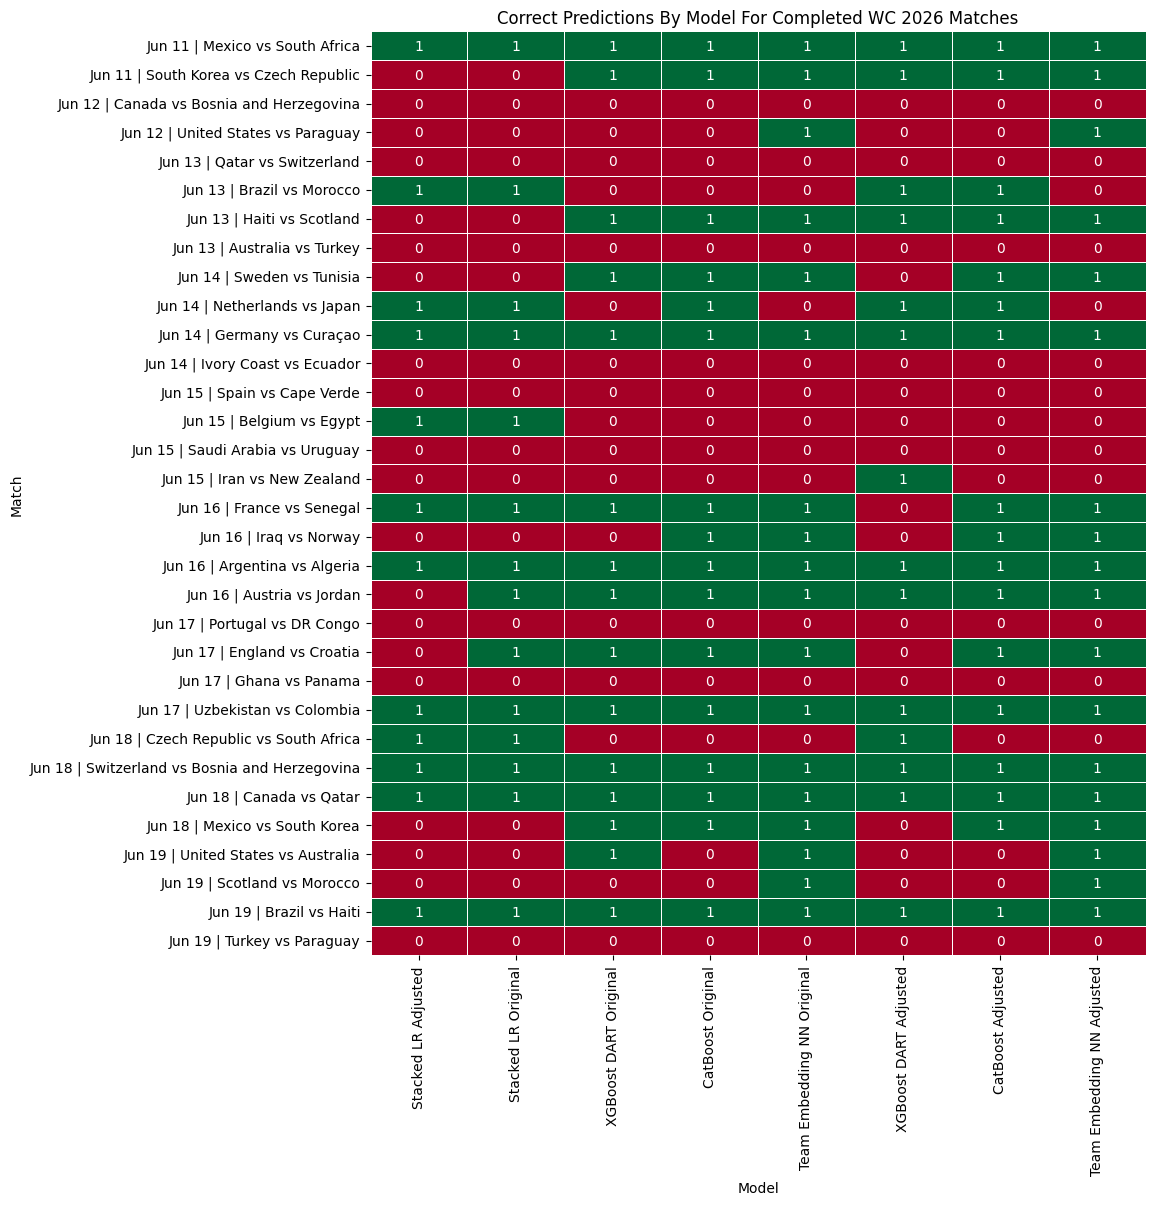

In [284]:
import seaborn as sns
correct_matrix = comparison[correct_cols].copy()
correct_matrix.columns = [
    col.replace("_pred_correct", "")
    for col in correct_matrix.columns
]

match_labels = (
    comparison["date"].dt.strftime("%b %d")
    + " | "
    + comparison["home_team"]
    + " vs "
    + comparison["away_team"]
)

plt.figure(figsize=(10, 12))
sns.heatmap(
    correct_matrix.astype(int),
    annot=True,
    cmap="RdYlGn",
    cbar=False,
    yticklabels=match_labels,
    linewidths=0.5,
)

plt.title("Correct Predictions By Model For Completed WC 2026 Matches")
plt.xlabel("Model")
plt.ylabel("Match")
plt.show()

### Model Prediction Comparison Against Completed WC 2026 Matches

This section compares every available model prediction against the World Cup 2026 matches that have already been played.

First, I collect all prediction tables that exist in the notebook, such as the stacked logistic regression model, the draw-adjusted stacked model, XGBoost DART, CatBoost and the team embedding neural network. If one model was not trained or is not available, it is skipped automatically.

Then I merge each model’s prediction with the real match results using:

- `date`
- `home_team`
- `away_team`

For every model, I create a new column showing whether its prediction was correct or wrong. This lets me see not only the total accuracy, but also exactly which matches each model missed.

The heatmap shows this visually:

- `1` means the model predicted the match result correctly.
- `0` means the model predicted the match result incorrectly.

This makes it easy to spot patterns, for example whether models are mostly missing draws, underdogs, or close matches.

I also calculate agreement between models. The column `model_agree_count` tells me how many models predicted the same result for a match. For example:

- `4` means four models agreed on the same prediction.
- `3` means three models agreed.
- `2` means only two models agreed.
- `1` means the models were mostly split.

The agreement summary checks whether model agreement actually improves reliability. If matches where all models agree are more accurate than matches where models disagree, then agreement can be used as a confidence signal.

This section is useful because it does not just ask “which model has the best accuracy?” It also checks when the models agree, where they fail, and whether disagreement can warn us that a prediction is risky.

### Model Agreement Summary

This table checks whether stronger agreement between models is a useful confidence signal.

- `models_available` shows how many models made a prediction for each match.
- `model_agree_count` shows the largest group of models that predicted the same result.
- `matches` shows how many completed matches fall into that agreement level.
- `average_correct_models` shows, on average, how many models were correct in those matches.
- `share_of_models_correct` converts that into a percentage of the available models.

For example, if `models_available = 5` and `model_agree_count = 5`, all five models predicted the same result. If `share_of_models_correct` is higher in that row, then full model agreement is a useful confidence signal.

This does not mean the prediction is guaranteed. It only tells us whether agreement between models tends to improve reliability.

In [285]:
agreement_summary = (
    comparison
    .groupby(["models_available", "model_agree_count"])
    .agg(
        matches=("actual_result", "size"),
        average_correct_models=("models_correct", "mean"),
    )
    .reset_index()
)

agreement_summary["share_of_models_correct"] = (
    agreement_summary["average_correct_models"] / agreement_summary["models_available"]
)

display(agreement_summary)

,models_available,model_agree_count,matches,average_correct_models,share_of_models_correct
0,8,4,2,4.000000,0.500000
1,8,5,9,2.555556,0.319444
2,8,6,6,3.666667,0.458333
3,8,7,3,5.000000,0.625000
4,8,8,12,4.666667,0.583333


### Actual vs Predicted Error Heatmap

This heatmap compares the real match result with each model’s predicted result.

The rows show the actual result:

- `home_win`
- `draw`
- `away_win`

The columns show the model prediction:

- `home_win`
- `draw`
- `away_win`

The diagonal cells are correct predictions, because the predicted result matches the actual result.

The off-diagonal cells are mistakes. For example:

- actual `draw`, predicted `home_win` means the match finished as a draw, but the model expected the home team to win.
- actual `draw`, predicted `away_win` means the match finished as a draw, but the model expected the away team to win.
- actual `home_win`, predicted `draw` means the home team won, but the model expected a draw.
- actual `away_win`, predicted `draw` means the away team won, but the model expected a draw.

This is useful because it shows what type of mistakes the model is making. In this project, the most important row to inspect is the `draw` row, because the models have often predicted a win when the real result was actually a draw.

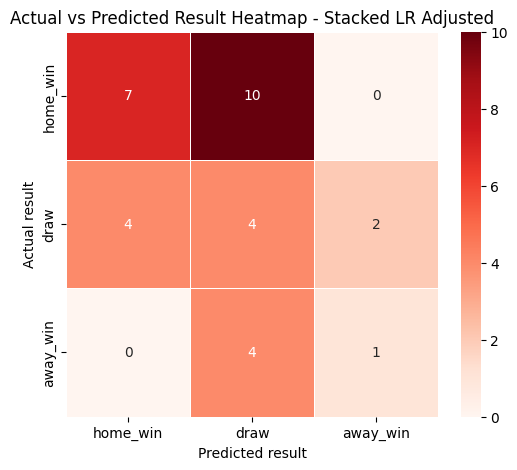

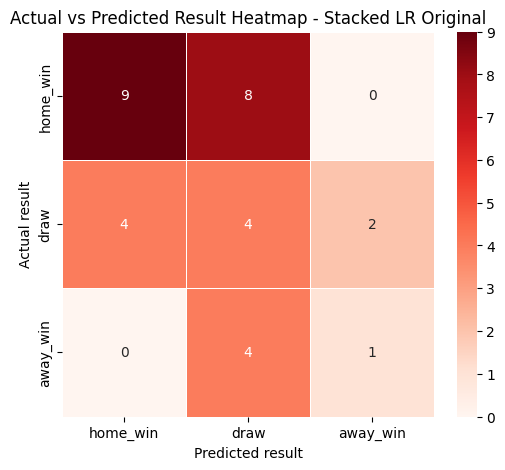

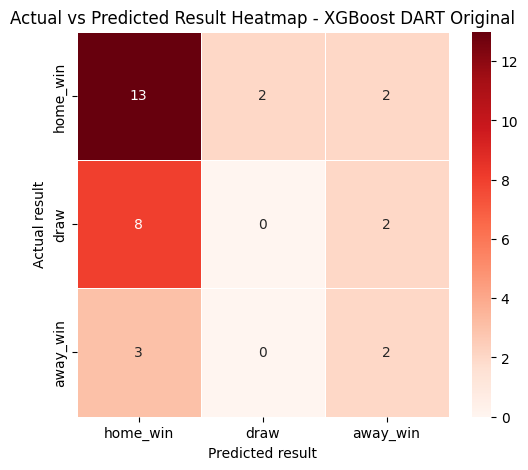

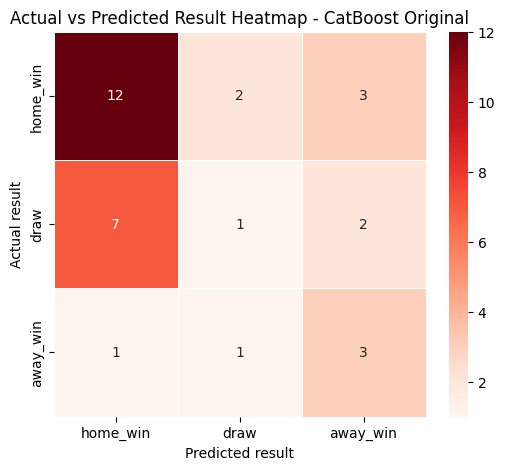

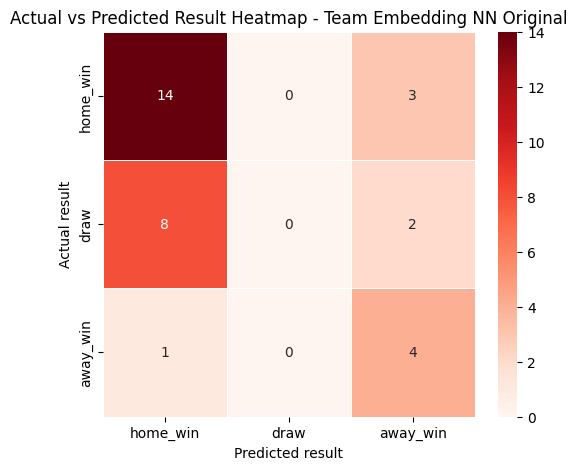

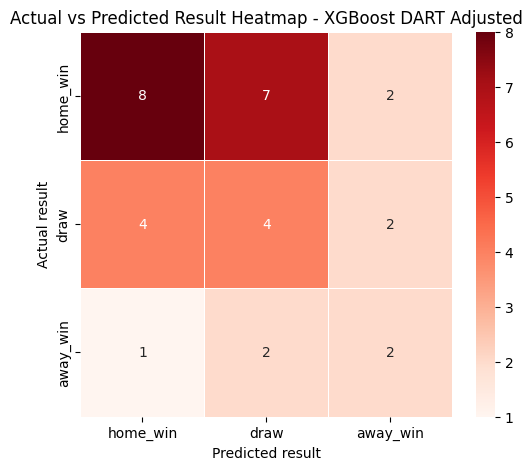

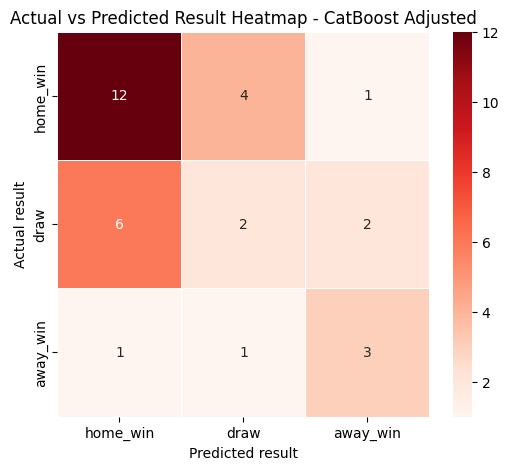

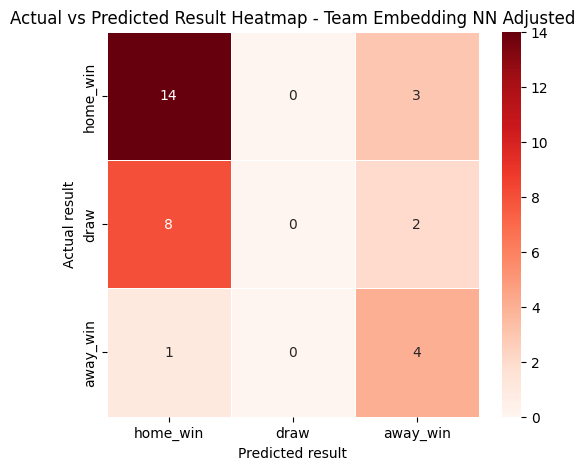

In [286]:
labels = ["home_win", "draw", "away_win"]

for col in model_cols:
    model_name = col.replace("_pred", "")

    error_table = pd.crosstab(
        comparison["actual_result"],
        comparison[col],
        rownames=["Actual result"],
        colnames=["Predicted result"],
        dropna=False,
    )

    error_table = error_table.reindex(index=labels, columns=labels, fill_value=0)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        error_table,
        annot=True,
        fmt="d",
        cmap="Reds",
        linewidths=0.5,
    )

    plt.title(f"Actual vs Predicted Result Heatmap - {model_name}")
    plt.xlabel("Predicted result")
    plt.ylabel("Actual result")
    plt.show()

## Meta-ensemble or mixture of experts

| Model | Best At | Worst At |
|---|---|---|
| Team Embedding NN Original | High-confidence matches, strong favorites | Draws, close games |
| CatBoost Adjusted | Detecting draws, balanced matches | High-confidence predictions |
| XGBoost DART Original | Mid-range confidence matches | Draws, away wins |
| Stacked LR Original | Away wins (80% recall) | Draws |

In [287]:
def classify_match(row):
    home_prob   = row.get("market_home_prob_norm", 0.33)
    away_prob   = row.get("market_away_prob_norm", 0.33)
    draw_prob   = float(row["draw_implied_prob"]) if pd.notna(row.get("draw_implied_prob")) else 0.20
    ranking_gap = abs(row.get("ranking_gap", 0))
    max_prob = max(home_prob, away_prob)
    if max_prob >= 0.65:
        return "one_sided"
    elif draw_prob >= 0.220: 
        return "draw_likely"
    elif ranking_gap <= 10:
        return "closely_matched"
    else:
        return "medium"


In [288]:
EXPERT_WEIGHTS = {
    "one_sided":        (0.10, 0.20, 0.25, 0.45),  # NN dominates — best at favorites
    "draw_likely":      (0.20, 0.65, 0.10, 0.05),  # CatBoost dominates — best draw detector
    "closely_matched":  (0.30, 0.35, 0.20, 0.15),  # LR + CatBoost — calibrated probabilities
    "medium":           (0.20, 0.45, 0.20, 0.15),  # your current locked weights
}

In [289]:
DRAW_BOOST_THRESHOLD  = 0.25
DRAW_BOOST_MULTIPLIER = 1.08

def mixture_of_experts(schedule_df, proba_stack, proba_cat, proba_xgb, proba_nn):
    final_proba = np.zeros_like(proba_stack)
    draw_idx = CLASS_ORDER.index("draw")
    for i, (_, row) in enumerate(schedule_df.iterrows()):
        match_type = classify_match(row)
        w = EXPERT_WEIGHTS[match_type]
        final_proba[i] = (
            w[0] * proba_stack[i] +
            w[1] * proba_cat[i]   +
            w[2] * proba_xgb[i]   +
            w[3] * proba_nn[i]
        )
        if match_type == "draw_likely":
            if final_proba[i, draw_idx] >= DRAW_BOOST_THRESHOLD:
                final_proba[i, draw_idx] *= DRAW_BOOST_MULTIPLIER
                final_proba[i] /= final_proba[i].sum()
    return final_proba


In [290]:
prob_cols = [c for c in schedule_group.columns if "prob" in c.lower() or "odds" in c.lower()]
print(prob_cols)

['home_spi_prob', 'away_spi_prob', 'draw_spi_prob', 'spi_prob_diff', 'has_market_odds', 'home_win_odds', 'draw_odds', 'away_win_odds', 'home_implied_prob', 'draw_implied_prob', 'away_implied_prob', 'market_home_prob_norm', 'market_draw_prob_norm', 'market_away_prob_norm', 'odds_prob_diff', 'market_favorite_prob', 'market_draw_prob', 'odds_source_id']


In [291]:
def score_by_match_type(results_df):
    for match_type in ["one_sided", "draw_likely", "closely_matched", "medium"]:
        subset = results_df[results_df["match_type"] == match_type]
        if len(subset) == 0:
            continue
        correct = (subset["predicted_result"] == subset["actual_result"]).sum()
        print(f"{match_type:<18}: {correct}/{len(subset)} = {correct/len(subset):.1%}")

In [292]:
preds = [CLASS_ORDER[i] for i in blended_proba.argmax(axis=1)]
pd.Series(preds).value_counts(normalize=True).round(3)


home_win    0.667
away_win    0.278
draw        0.056
Name: proportion, dtype: float64

In [293]:
match_types = [classify_match(row) for _, row in schedule_group.iterrows()]
pd.Series(match_types).value_counts()

draw_likely        31
one_sided          29
medium             11
closely_matched     1
Name: count, dtype: int64

In [294]:
cat_preds = [CLASS_ORDER[i] for i in proba_cat.argmax(axis=1)]
pd.Series(cat_preds).value_counts(normalize=True).round(3)

home_win    0.736
away_win    0.250
draw        0.014
Name: proportion, dtype: float64

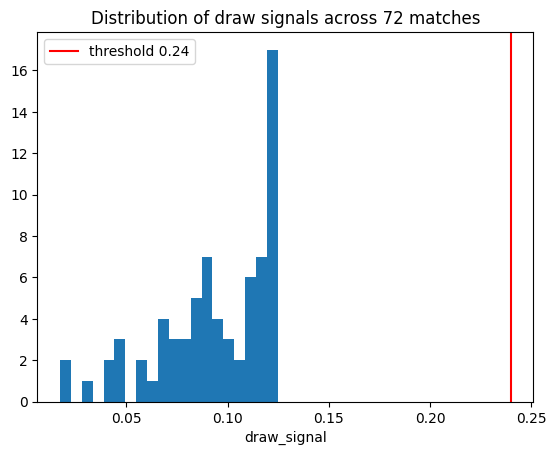

Matches above threshold 0.24: 0/72


In [295]:
signals = []
for _, row in schedule_group.iterrows():
    draw_prob = row.get("market_draw_prob_norm", 0.33)
    spi_draw  = row.get("draw_spi_prob", 0.25)
    signals.append((draw_prob + spi_draw) / 2)

import matplotlib.pyplot as plt
plt.hist(signals, bins=20)
plt.axvline(0.24, color='red', label='threshold 0.24')
plt.xlabel("draw_signal")
plt.title("Distribution of draw signals across 72 matches")
plt.legend()
plt.show()

print(f"Matches above threshold 0.24: {sum(s >= 0.24 for s in signals)}/72")

In [296]:
print(schedule_group.columns.tolist())

['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'result', 'home_low_history_team', 'away_low_history_team', 'match_importance', 'home_score_capped', 'away_score_capped', 'is_extreme_scoreline', 'goal_diff', 'total_goals', 'home_elo_is_home', 'home_elo', 'away_elo_is_home', 'away_elo', 'elo_diff', 'home_fifa_points', 'home_fifa_rank', 'home_fifa_points_zscore', 'fifa_points_percentile_by_date_x', 'teams_in_ranking_date_x', 'is_fifa_zscore_outlier_x', 'is_small_ranking_date_x', 'is_partial_fifa_ranking_date_x', 'away_fifa_points', 'away_fifa_rank', 'away_fifa_points_zscore', 'fifa_points_percentile_by_date_y', 'teams_in_ranking_date_y', 'is_fifa_zscore_outlier_y', 'is_small_ranking_date_y', 'is_partial_fifa_ranking_date_y', 'fifa_rank_diff', 'fifa_points_zscore_diff', 'home_form_score_5', 'home_form_score_10', 'home_has_full_form_5', 'home_has_any_form_5', 'home_has_full_form_10', 'home_has_any_form_10', 'away_form_score_5', 'awa

In [297]:
TODAY = pd.Timestamp("2026-06-20")

played_mask   = schedule_group["date"] < TODAY
upcoming_mask = schedule_group["date"] >= TODAY

played_matches   = schedule_group[played_mask].copy()
upcoming_matches = schedule_group[upcoming_mask].copy()

print(f"Played matches (need real results): {len(played_matches)}")
print(f"Upcoming matches (model predicts):  {len(upcoming_matches)}")
print(upcoming_matches[["date", "home_team", "away_team", "group"]].to_string())

Played matches (need real results): 32
Upcoming matches (model predicts):  40
         date               home_team       away_team group
32 2026-06-20                 Germany     Ivory Coast     I
33 2026-06-20                 Ecuador         Curaçao     I
34 2026-06-20             Netherlands          Sweden     L
35 2026-06-20                 Tunisia           Japan     L
36 2026-06-21                 Uruguay      Cape Verde     F
37 2026-06-21                 Belgium            Iran     C
38 2026-06-21             New Zealand           Egypt     C
39 2026-06-21                   Spain    Saudi Arabia     F
40 2026-06-22                  Jordan         Algeria     A
41 2026-06-22               Argentina         Austria     A
42 2026-06-22                  Norway         Senegal     K
43 2026-06-22                  France            Iraq     K
44 2026-06-23                Portugal      Uzbekistan     G
45 2026-06-23                Colombia        DR Congo     G
46 2026-06-23         

In [298]:
schedule_group = schedule_model[schedule_model["tournament_stage"] == 1].copy()
print(schedule_model["match_stage_status"].value_counts())
print(schedule_model["stage"].value_counts())


match_stage_status
Predictable    72
Placeholder    32
Name: count, dtype: int64
Series([], Name: count, dtype: int64)


In [299]:
schedule_group = schedule_model[schedule_model["match_stage_status"] == "Predictable"].copy()
TODAY = pd.Timestamp("2026-06-20")
played_mask   = schedule_group["date"] < TODAY
upcoming_mask = schedule_group["date"] >= TODAY
played_matches   = schedule_group[played_mask].copy()
upcoming_matches = schedule_group[upcoming_mask].copy()
print(f"Total predictable: {len(schedule_group)}")
print(f"Played:   {len(played_matches)}")
print(f"Upcoming: {len(upcoming_matches)}")
print()
print(upcoming_matches[["date", "home_team", "away_team", "group"]].to_string())


Total predictable: 72
Played:   32
Upcoming: 40

         date               home_team       away_team group
32 2026-06-20                 Germany     Ivory Coast     I
33 2026-06-20                 Ecuador         Curaçao     I
34 2026-06-20             Netherlands          Sweden     L
35 2026-06-20                 Tunisia           Japan     L
36 2026-06-21                 Uruguay      Cape Verde     F
37 2026-06-21                 Belgium            Iran     C
38 2026-06-21             New Zealand           Egypt     C
39 2026-06-21                   Spain    Saudi Arabia     F
40 2026-06-22                  Jordan         Algeria     A
41 2026-06-22               Argentina         Austria     A
42 2026-06-22                  Norway         Senegal     K
43 2026-06-22                  France            Iraq     K
44 2026-06-23                Portugal      Uzbekistan     G
45 2026-06-23                Colombia        DR Congo     G
46 2026-06-23                 England           Gha

In [300]:
print(played_matches[["date", "home_team", "away_team", "group", "result", "home_score", "away_score"]].to_string())

         date       home_team               away_team group result  home_score  away_score
0  2026-06-11          Mexico            South Africa     J    NaN         NaN         NaN
1  2026-06-11     South Korea          Czech Republic     J    NaN         NaN         NaN
2  2026-06-12          Canada  Bosnia and Herzegovina     D    NaN         NaN         NaN
3  2026-06-12   United States                Paraguay     B    NaN         NaN         NaN
4  2026-06-13           Qatar             Switzerland     D    NaN         NaN         NaN
5  2026-06-13          Brazil                 Morocco     E    NaN         NaN         NaN
6  2026-06-13           Haiti                Scotland     E    NaN         NaN         NaN
7  2026-06-13       Australia                  Turkey     B    NaN         NaN         NaN
8  2026-06-14         Germany                 Curaçao     I    NaN         NaN         NaN
9  2026-06-14     Ivory Coast                 Ecuador     I    NaN         NaN         NaN

In [301]:
schedule_group["pred_away_win"]  = blended_proba[:, CLASS_ORDER.index("away_win")]
schedule_group["pred_draw"]      = blended_proba[:, CLASS_ORDER.index("draw")]
schedule_group["pred_home_win"]  = blended_proba[:, CLASS_ORDER.index("home_win")]
schedule_group["pred_result"]    = [CLASS_ORDER[i] for i in blended_proba.argmax(axis=1)]

sched = schedule_group.drop(columns=["actual_result","home_score_actual","away_score_actual"], errors="ignore")

sched = sched.merge(
    actual_results_2026[["date","home_team","away_team","home_score","away_score","actual_result"]],
    on=["date","home_team","away_team"],
    how="left"
)


sched["final_result"] = sched["actual_result"].combine_first(sched["pred_result"])


print(f"Real results filled: {sched['actual_result'].notna().sum()}")
print(f"Model predictions:   {sched['pred_result'].notna().sum()}")
print(sched[["date","home_team","away_team","group","actual_result","pred_result","final_result"]].to_string())

Real results filled: 32
Model predictions:   72
         date               home_team               away_team group actual_result pred_result final_result
0  2026-06-11                  Mexico            South Africa     J      home_win    home_win     home_win
1  2026-06-11             South Korea          Czech Republic     J      home_win    home_win     home_win
2  2026-06-12                  Canada  Bosnia and Herzegovina     D          draw    home_win         draw
3  2026-06-12           United States                Paraguay     B      home_win    home_win     home_win
4  2026-06-13                   Qatar             Switzerland     D          draw    away_win         draw
5  2026-06-13                  Brazil                 Morocco     E          draw    home_win         draw
6  2026-06-13                   Haiti                Scotland     E      away_win    away_win     away_win
7  2026-06-13               Australia                  Turkey     B      home_win    away_win   

In [302]:
proba_stack = align_proba(stack_model,          make_stacking_features(schedule_gnn, full_base_model, odds_base_model))
proba_cat   = align_proba(cat_model_calibrated, schedule_gnn[xgb_feature_cols])
proba_xgb   = align_proba(xgb_dart_calibrated,  schedule_gnn[xgb_feature_cols])
proba_nn    = gnn_proba if (globals().get("gnn_proba") is not None) else proba_stack

moe_proba = mixture_of_experts(schedule_gnn, proba_stack, proba_cat, proba_xgb, proba_nn)

schedule_group["pred_away_win"] = moe_proba[:, CLASS_ORDER.index("away_win")]
schedule_group["pred_draw"]     = moe_proba[:, CLASS_ORDER.index("draw")]
schedule_group["pred_home_win"] = moe_proba[:, CLASS_ORDER.index("home_win")]
schedule_group["pred_result"]   = [CLASS_ORDER[i] for i in moe_proba.argmax(axis=1)]

print("MoE predictions done:")
print(pd.Series(schedule_group["pred_result"]).value_counts())

MoE predictions done:
pred_result
home_win    43
draw        16
away_win    13
Name: count, dtype: int64


In [303]:
from sklearn.linear_model import PoissonRegressor
from xgboost import XGBRegressor
train_df_goals = full_df[full_df["home_score"].notna() & full_df["away_score"].notna()].copy()
xgb_feature_cols_goals = [c for c in xgb_feature_cols if c in train_df_goals.columns]
X_goals = train_df_goals[xgb_feature_cols_goals].fillna(0)
y_home_goals = train_df_goals["home_goals"] if "home_goals" in train_df_goals.columns else train_df_goals["home_score"]
y_away_goals = train_df_goals["away_goals"] if "away_goals" in train_df_goals.columns else train_df_goals["away_score"]
y_home_goals = y_home_goals.astype(int)
y_away_goals = y_away_goals.astype(int)
poisson_home_model = PoissonRegressor(max_iter=1000)
poisson_home_model.fit(X_goals, y_home_goals)
poisson_away_model = PoissonRegressor(max_iter=1000)
poisson_away_model.fit(X_goals, y_away_goals)
xgb_home_model = XGBRegressor(objective="count:poisson", random_state=42)
xgb_home_model.fit(X_goals, y_home_goals)
xgb_away_model = XGBRegressor(objective="count:poisson", random_state=42)
xgb_away_model.fit(X_goals, y_away_goals)


,objective,'count:poisson'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [304]:
sched = schedule_group.copy()
sched = sched.drop(columns=["actual_result", "home_score_actual", "away_score_actual"], errors="ignore")
sched = sched.merge(
    actual_results_2026[["date","home_team","away_team","home_score","away_score","actual_result"]].rename(columns={
        "home_score": "actual_home_score",
        "away_score": "actual_away_score"
    }),
    on=["date","home_team","away_team"],
    how="left"
)
sched["final_result"] = sched["actual_result"].combine_first(sched["pred_result"])
predicted_home_goals = []
predicted_away_goals = []
for _, r in sched.iterrows():
    X_f = r[xgb_feature_cols_goals].to_frame().T.fillna(0)
    p_home = poisson_home_model.predict(X_f)[0]
    x_home = xgb_home_model.predict(X_f)[0]
    p_away = poisson_away_model.predict(X_f)[0]
    x_away = xgb_away_model.predict(X_f)[0]
    predicted_home_goals.append(int(round(0.70 * p_home + 0.30 * x_home)))
    predicted_away_goals.append(int(round(0.70 * p_away + 0.30 * x_away)))
sched["final_home_score"] = sched["actual_home_score"].combine_first(pd.Series(predicted_home_goals, index=sched.index))
sched["final_away_score"] = sched["actual_away_score"].combine_first(pd.Series(predicted_away_goals, index=sched.index))
print(f"Real results: {sched['actual_result'].notna().sum()}")
print(f"Predicted:    {sched['pred_result'].notna().sum()}")
print(sched[["date","home_team","away_team","group","actual_result","pred_result","final_result","final_home_score","final_away_score"]].to_string())


Real results: 32
Predicted:    72
         date               home_team               away_team group actual_result pred_result final_result  final_home_score  final_away_score
0  2026-06-11                  Mexico            South Africa     J      home_win    home_win     home_win               2.0               0.0
1  2026-06-11             South Korea          Czech Republic     J      home_win    home_win     home_win               2.0               1.0
2  2026-06-12                  Canada  Bosnia and Herzegovina     D          draw    home_win         draw               1.0               1.0
3  2026-06-12           United States                Paraguay     B      home_win        draw     home_win               4.0               1.0
4  2026-06-13                   Qatar             Switzerland     D          draw    away_win         draw               1.0               1.0
5  2026-06-13                  Brazil                 Morocco     E          draw        draw         draw  

In [305]:
schedule2026 = schedule_2026
def get_team_avg_stats(team, df):
    home_matches = df[df["home_team"] == team]
    away_matches = df[df["away_team"] == team]
    if home_matches.empty and away_matches.empty:
        return None
    stats = {}
    for col in df.columns:
        if col.startswith("home_"):
            base_name = col[5:]
            away_col = f"away_{base_name}"
            if away_col in df.columns:
                vals = []
                if not home_matches.empty:
                    vals.extend(home_matches[col].dropna().tolist())
                if not away_matches.empty:
                    vals.extend(away_matches[away_col].dropna().tolist())
                if vals:
                    try:
                        numeric_vals = [float(v) for v in vals]
                        stats[base_name] = np.mean(numeric_vals)
                    except ValueError:
                        stats[base_name] = max(set(vals), key=vals.count)
    return stats

def adjust_for_favorites(team_a, team_b, pa, pb, fulldf):
    stats_a = get_team_avg_stats(team_a, fulldf)
    stats_b = get_team_avg_stats(team_b, fulldf)
    if stats_a and stats_b:
        elo_a = float(stats_a.get("elo", 1500))
        elo_b = float(stats_b.get("elo", 1500))
        elo_diff = elo_a - elo_b
        if abs(elo_diff) >= 50:
            p_elo_a = 1 / (1 + 10**(-elo_diff / 400))
            p_elo_b = 1 - p_elo_a
            weight_elo = min(0.95, abs(elo_diff) / 200.0)
            pa = (1 - weight_elo) * pa + weight_elo * p_elo_a
            pb = (1 - weight_elo) * pb + weight_elo * p_elo_b
            if abs(elo_diff) >= 150:
                if elo_diff > 0:
                    pa += 0.10
                    pb -= 0.10
                else:
                    pb += 0.10
                    pa -= 0.10
                total = pa + pb
                pa, pb = pa / total, pb / total
    return pa, pb

def build_matchup_features(team_a, team_b, fulldf, xgb_feature_cols):
    stats_a = get_team_avg_stats(team_a, fulldf)
    stats_b = get_team_avg_stats(team_b, fulldf)
    if stats_a is None or stats_b is None:
        return None
    row = schedule_gnn.iloc[0:1].copy()
    row["home_team"] = team_a
    row["away_team"] = team_b
    for col in row.columns:
        if col.startswith("home_"):
            base_name = col[5:]
            if base_name in stats_a:
                row[col] = stats_a[base_name]
        elif col.startswith("away_"):
            base_name = col[5:]
            if base_name in stats_b:
                row[col] = stats_b[base_name]
    diff_mappings = {
        "odds_prob_diff": 0.0,
        "xg_attack_diff": lambda sa, sb: float(sa.get("xg_for_rolling", 0)) - float(sb.get("xg_for_rolling", 0)),
        "xg_defense_diff": lambda sa, sb: float(sa.get("xg_against_rolling", 0)) - float(sb.get("xg_against_rolling", 0)),
        "xg_balance_diff": lambda sa, sb: (float(sa.get("xg_for_rolling", 0)) - float(sa.get("xg_against_rolling", 0))) - (float(sb.get("xg_for_rolling", 0)) - float(sb.get("xg_against_rolling", 0))),
        "unavailable_diff": lambda sa, sb: float(sa.get("total_unavailable", 0)) - float(sb.get("total_unavailable", 0)),
        "missing_player_value_diff": lambda sa, sb: float(sa.get("missing_player_value", 0)) - float(sb.get("missing_player_value", 0)),
        "squad_value_diff": lambda sa, sb: float(sa.get("squad_value_eur_m", 0)) - float(sb.get("squad_value_eur_m", 0)),
        "top_player_value_diff": lambda sa, sb: float(sa.get("top_player_value_eur_m", 0)) - float(sb.get("top_player_value_eur_m", 0)),
        "strength_rating_diff": lambda sa, sb: float(sa.get("overall_rating", 0)) - float(sb.get("overall_rating", 0)),
        "attack_rating_diff": lambda sa, sb: float(sa.get("attack_rating", 0)) - float(sb.get("attack_rating", 0)),
        "defense_rating_diff": lambda sa, sb: float(sa.get("defense_rating", 0)) - float(sb.get("defense_rating", 0)),
        "h2h_wins_diff": 0.0,
        "h2h_goals_diff": 0.0,
        "h2h_avg_goals_diff": 0.0,
        "win_streak_diff": lambda sa, sb: float(sa.get("win_streak", 0)) - float(sb.get("win_streak", 0)),
        "unbeaten_streak_diff": lambda sa, sb: float(sa.get("unbeaten_streak", 0)) - float(sb.get("unbeaten_streak", 0)),
        "fifa_rank_diff": lambda sa, sb: float(sa.get("fifa_rank", 0)) - float(sb.get("fifa_rank", 0)),
        "fifa_points_zscore_diff": lambda sa, sb: float(sa.get("fifa_points_zscore", 0)) - float(sb.get("fifa_points_zscore", 0)),
        "form_score_5_diff": lambda sa, sb: float(sa.get("form_score_5", 0)) - float(sb.get("form_score_5", 0)),
        "form_score_10_diff": lambda sa, sb: float(sa.get("form_score_10", 0)) - float(sb.get("form_score_10", 0)),
        "form_trend_diff": lambda sa, sb: float(sa.get("form_trend", 0)) - float(sb.get("form_trend", 0)),
        "elo_diff": lambda sa, sb: float(sa.get("elo", 0)) - float(sb.get("elo", 0)),
        "attack_diff": lambda sa, sb: float(sa.get("attack_rating", 0)) - float(sb.get("attack_rating", 0)),
        "defense_diff": lambda sa, sb: float(sa.get("defense_rating", 0)) - float(sb.get("defense_rating", 0)),
        "rest_days_diff": 0.0
    }
    for col, value in diff_mappings.items():
        if col in row.columns:
            if callable(value):
                row[col] = value(stats_a, stats_b)
            else:
                row[col] = value
    row["neutral"] = 1
    row["is_neutral_venue"] = 1
    row["is_home_country"] = 0
    row["group_stage_match_day"] = 4
    row["market_favorite_prob"] = 0.33
    row["market_draw_prob"] = 0.33
    row["odds_prob_diff"] = 0.0
    return row.fillna(0)

def predict_knockout(team_a, team_b):
    row = sched[(sched["home_team"]==team_a) & (sched["away_team"]==team_b)]
    feat_row = None
    if not row.empty:
        pa = float(row.iloc[0]["pred_home_win"]) + float(row.iloc[0]["pred_draw"]) * 0.5
        pb = float(row.iloc[0]["pred_away_win"]) + float(row.iloc[0]["pred_draw"]) * 0.5
        feat_row = row.iloc[0:1]
    else:
        row = sched[(sched["home_team"]==team_b) & (sched["away_team"]==team_a)]
        if not row.empty:
            pb = float(row.iloc[0]["pred_home_win"]) + float(row.iloc[0]["pred_draw"]) * 0.5
            pa = float(row.iloc[0]["pred_away_win"]) + float(row.iloc[0]["pred_draw"]) * 0.5
            feat_row = row.iloc[0:1]
        else:
            feat_row = build_matchup_features(team_a, team_b, full_df, xgb_feature_cols)
            if feat_row is not None:
                feat_row_for_stack = make_stacking_features(feat_row, full_base_model, odds_base_model)
                p_stack = align_proba(stack_model, feat_row_for_stack)
                p_cat   = align_proba(cat_model_calibrated, feat_row[xgb_feature_cols])
                p_xgb   = align_proba(xgb_dart_calibrated,  feat_row[xgb_feature_cols])
                p_nn    = p_stack
                home_win_idx = CLASS_ORDER.index("home_win")
                away_win_idx = CLASS_ORDER.index("away_win")
                p_stack_home, p_stack_away = p_stack[0, home_win_idx], p_stack[0, away_win_idx]
                p_cat_home, p_cat_away = p_cat[0, home_win_idx], p_cat[0, away_win_idx]
                p_xgb_home, p_xgb_away = p_xgb[0, home_win_idx], p_xgb[0, away_win_idx]
                blended_home = 0.20 * p_stack_home + 0.45 * p_cat_home + 0.20 * p_xgb_home + 0.15 * p_stack_home
                blended_away = 0.20 * p_stack_away + 0.45 * p_cat_away + 0.20 * p_xgb_away + 0.15 * p_stack_away
                total_win_prob = blended_home + blended_away
                if total_win_prob > 0:
                    pa = blended_home / total_win_prob
                    pb = blended_away / total_win_prob
                else:
                    pa, pb = 0.5, 0.5
            else:
                def get_elo(team):
                    r = full_df[full_df["home_team"]==team].tail(3)
                    return float(r["home_elo"].mean()) if len(r) else 1500.0
                elo_a, elo_b = get_elo(team_a), get_elo(team_b)
                pa = 1 / (1 + 10**((elo_b - elo_a)/400))
                pb = 1 - pa
    pa, pb = adjust_for_favorites(team_a, team_b, pa, pb, full_df)
    if feat_row is not None:
        X_feat = feat_row[xgb_feature_cols_goals].fillna(0)
        p_home = poisson_home_model.predict(X_feat)[0]
        x_home = xgb_home_model.predict(X_feat)[0]
        p_away = poisson_away_model.predict(X_feat)[0]
        x_away = xgb_away_model.predict(X_feat)[0]
        score_a = int(round(0.70 * p_home + 0.30 * x_home))
        score_b = int(round(0.70 * p_away + 0.30 * x_away))
    else:
        score_a, score_b = 1, 1
    winner = team_a if pa >= pb else team_b
    return winner, round(pa, 3), round(pb, 3), score_a, score_b


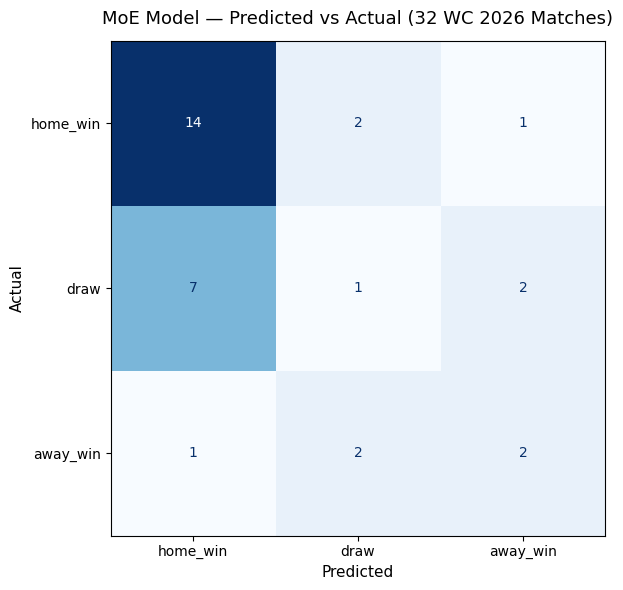


Overall accuracy on 32 played matches: 53.1%
pred_result    away_win  draw  home_win
actual_result                          
away_win              2     2         1
draw                  2     1         7
home_win              1     2        14


In [306]:
from sklearn.metrics import ConfusionMatrixDisplay
played = sched[sched["actual_result"].notna()].copy()

labels = ["home_win", "draw", "away_win"]
cm = confusion_matrix(played["actual_result"], played["pred_result"], labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title("MoE Model — Predicted vs Actual (32 WC 2026 Matches)", fontsize=13, pad=12)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual", fontsize=11)
plt.tight_layout()
plt.savefig("moe_confusion_matrix.png", dpi=150)
plt.show()

acc = (played["actual_result"] == played["pred_result"]).mean()
print(f"\nOverall accuracy on 32 played matches: {acc:.1%}")
print(played.groupby(["actual_result","pred_result"]).size().unstack(fill_value=0))

In [307]:
def compute_group_standings(sched):
    records = []
    for _, row in sched.iterrows():
        ht, at = row["home_team"], row["away_team"]
        grp    = row["group"]
        res    = row["final_result"]
        hs     = row["actual_home_score"] if pd.notna(row.get("actual_home_score")) else (1 if res=="home_win" else 0)
        as_    = row["actual_away_score"] if pd.notna(row.get("actual_away_score")) else (1 if res=="away_win" else 0)

        if res == "home_win":
            hp, ap = 3, 0
        elif res == "away_win":
            hp, ap = 0, 3
        else:
            hp, ap = 1, 1

        records.append({"team": ht, "group": grp, "pts": hp, "gf": hs, "ga": as_, "gd": hs - as_})
        records.append({"team": at, "group": grp, "pts": ap, "gf": as_, "ga": hs, "gd": as_ - hs})

    df = pd.DataFrame(records)
    standings = (df.groupby(["group","team"])
                   .agg(pts=("pts","sum"), gf=("gf","sum"), ga=("ga","sum"), gd=("gd","sum"))
                   .reset_index())
    standings["played"] = sched.groupby("group").size().reindex(standings["group"].values).values // 2 + \
                          (sched.groupby("group").size().reindex(standings["group"].values).values % 2)
    standings = standings.sort_values(["group","pts","gd","gf"], ascending=[True,False,False,False])
    return standings

standings = compute_group_standings(sched)
print(standings.to_string(index=False))

group                   team  pts  gf  ga   gd  played
    A              Argentina    9 5.0 0.0  5.0       3
    A                Austria    4 3.0 2.0  1.0       3
    A                Algeria    2 0.0 3.0 -3.0       3
    A                 Jordan    1 1.0 4.0 -3.0       3
    B          United States    7 6.0 1.0  5.0       3
    B              Australia    4 2.0 2.0  0.0       3
    B               Paraguay    4 2.0 4.0 -2.0       3
    B                 Turkey    1 0.0 3.0 -3.0       3
    C                Belgium    5 2.0 1.0  1.0       3
    C                  Egypt    5 2.0 1.0  1.0       3
    C                   Iran    3 2.0 2.0  0.0       3
    C            New Zealand    1 2.0 4.0 -2.0       3
    D                 Canada    5 7.0 1.0  6.0       3
    D            Switzerland    5 5.0 2.0  3.0       3
    D Bosnia and Herzegovina    4 3.0 5.0 -2.0       3
    D                  Qatar    1 1.0 8.0 -7.0       3
    E                Morocco    7 3.0 1.0  2.0       3
    E     

In [308]:
top2 = standings.groupby("group").head(2)

third_place = standings.groupby("group").nth(2).reset_index()
third_place_sorted = third_place.sort_values(["pts","gd","gf"], ascending=[False,False,False])
best8_third = third_place_sorted.head(8)

qualifiers = pd.concat([top2, best8_third]).reset_index(drop=True)
qualifiers["finish"] = qualifiers.groupby("group").cumcount() + 1
qualifiers.loc[qualifiers["team"].isin(best8_third["team"].values), "finish"] = 3

print("=== 32 QUALIFIERS ===")
print(qualifiers[["group","finish","team","pts","gd","gf"]].to_string(index=False))
print(f"\nTotal: {len(qualifiers)}")

=== 32 QUALIFIERS ===
group  finish                   team  pts   gd  gf
    A       1              Argentina    9  5.0 5.0
    A       2                Austria    4  1.0 3.0
    B       1          United States    7  5.0 6.0
    B       2              Australia    4  0.0 2.0
    C       1                Belgium    5  1.0 2.0
    C       2                  Egypt    5  1.0 2.0
    D       1                 Canada    5  6.0 7.0
    D       2            Switzerland    5  3.0 5.0
    E       1                Morocco    7  2.0 3.0
    E       2               Scotland    6  1.0 2.0
    F       1                  Spain    7  2.0 2.0
    F       2                Uruguay    4  0.0 2.0
    G       1               Colombia    7  3.0 4.0
    G       2               Portugal    5  1.0 2.0
    H       1                England    6  2.0 5.0
    H       2                Croatia    6  0.0 4.0
    I       1                Germany    7  7.0 8.0
    I       2            Ivory Coast    6  1.0 2.0
    J    

In [309]:
r32_fixtures = [
    ("A1", "B2"), ("C1", "D2"), ("E1", "F2"), ("G1", "H2"),
    ("I1", "J2"), ("K1", "L2"), ("B1", "A2"), ("D1", "C2"),
    ("F1", "E2"), ("H1", "G2"), ("J1", "I2"), ("L1", "K2"),
    ("A1", "3rd-BCD"), ("B1", "3rd-AEF"), ("C1", "3rd-GHI"),
    ("D1", "3rd-JKL"),
]


def get_team(group, finish, qualifiers):
    row = qualifiers[(qualifiers["group"]==group) & (qualifiers["finish"]==finish)]
    if len(row): return row.iloc[0]["team"]
    return None

def get_3rd(groups, qualifiers):
    thirds = qualifiers[qualifiers["finish"]==3]
    match = thirds[thirds["group"].isin(list(groups))]
    return match.sort_values(["pts","gd","gf"], ascending=[False,False,False]).iloc[0]["team"]

r32 = [
    (get_team("A",1,qualifiers), get_team("B",2,qualifiers)),
    (get_team("C",1,qualifiers), get_team("D",2,qualifiers)),
    (get_team("E",1,qualifiers), get_team("F",2,qualifiers)),
    (get_team("G",1,qualifiers), get_team("H",2,qualifiers)),
    (get_team("I",1,qualifiers), get_team("J",2,qualifiers)),
    (get_team("K",1,qualifiers), get_team("L",2,qualifiers)),
    (get_team("B",1,qualifiers), get_team("A",2,qualifiers)),
    (get_team("D",1,qualifiers), get_team("C",2,qualifiers)),
    (get_team("F",1,qualifiers), get_team("E",2,qualifiers)),
    (get_team("H",1,qualifiers), get_team("G",2,qualifiers)),
    (get_team("J",1,qualifiers), get_team("I",2,qualifiers)),
    (get_team("L",1,qualifiers), get_team("K",2,qualifiers)),
    (get_team("A",1,qualifiers), get_3rd("BCD", qualifiers)),
    (get_team("B",1,qualifiers), get_3rd("AEF", qualifiers)),
    (get_team("C",1,qualifiers), get_3rd("GHI", qualifiers)),
    (get_team("D",1,qualifiers), get_3rd("JKL", qualifiers)),
]

print("=== ROUND OF 32 ===")
for i,(h,a) in enumerate(r32):
    print(f"  M{i+1:02d}: {h} vs {a}")

=== ROUND OF 32 ===
  M01: Argentina vs Australia
  M02: Belgium vs Switzerland
  M03: Morocco vs Uruguay
  M04: Colombia vs Croatia
  M05: Germany vs South Africa
  M06: France vs Japan
  M07: United States vs Austria
  M08: Canada vs Egypt
  M09: Spain vs Scotland
  M10: England vs Portugal
  M11: Mexico vs Ivory Coast
  M12: Netherlands vs Norway
  M13: Argentina vs Bosnia and Herzegovina
  M14: United States vs Brazil
  M15: Belgium vs Ecuador
  M16: Canada vs Sweden


In [310]:
third_teams = qualifiers[qualifiers["finish"]==3][["group","team"]].set_index("group")["team"].to_dict()
print("3rd place qualifiers:", third_teams)

third_pool = dict(third_teams)

def assign_and_remove(pool, slot_groups):
    eligible = {g: t for g, t in pool.items() if g in slot_groups}
    if not eligible:
        return "TBD"
    eligible_df = qualifiers[qualifiers["team"].isin(eligible.values())].sort_values(
        ["pts","gd","gf"], ascending=[True, True, True])  # ← worst first
    winner = eligible_df.iloc[0]["team"]
    winner_group = [g for g, t in pool.items() if t == winner][0]
    del pool[winner_group]
    return winner

g1 = {g: get_team(g, 1, qualifiers) for g in "ABCDEFGHIJKL"}
g2 = {g: get_team(g, 2, qualifiers) for g in "ABCDEFGHIJKL"}

r32 = {}
r32[73] = (g2["A"],  g2["B"])
r32[74] = (g1["E"],  assign_and_remove(third_pool, "ABCDF"))
r32[75] = (g1["F"],  g2["C"])
r32[76] = (g1["C"],  g2["F"])
r32[77] = (g1["I"],  assign_and_remove(third_pool, "CDFGH"))
r32[78] = (g2["E"],  g2["I"])
r32[79] = (g1["A"],  assign_and_remove(third_pool, "CEFHI"))
r32[80] = (g1["L"],  assign_and_remove(third_pool, "EHIJK"))
r32[81] = (g1["D"],  assign_and_remove(third_pool, "BEFIJ"))
r32[82] = (g1["G"],  assign_and_remove(third_pool, "AEHIJ"))
r32[83] = (g2["K"],  g2["L"])
r32[84] = (g1["H"],  g2["J"])
r32[85] = (g1["B"],  assign_and_remove(third_pool, "EFGIJ"))
r32[86] = (g1["J"],  g2["H"])
r32[87] = (g1["K"],  assign_and_remove(third_pool, "DEIJL"))
r32[88] = (g2["D"],  g2["G"])

print("\n=== OFFICIAL R32 BRACKET ===")
for m, (h, a) in r32.items():
    print(f"  M{m}: {h} vs {a}")

3rd place qualifiers: {'E': 'Brazil', 'I': 'Ecuador', 'D': 'Bosnia and Herzegovina', 'B': 'Paraguay', 'L': 'Sweden', 'C': 'Iran', 'J': 'South Korea', 'H': 'Ghana'}

=== OFFICIAL R32 BRACKET ===
  M73: Austria vs Australia
  M74: Morocco vs Iran
  M75: Spain vs Egypt
  M76: Belgium vs Uruguay
  M77: Germany vs Ghana
  M78: Scotland vs Ivory Coast
  M79: Argentina vs Ecuador
  M80: Netherlands vs South Korea
  M81: Canada vs Paraguay
  M82: Colombia vs Brazil
  M83: Norway vs Japan
  M84: England vs South Africa
  M85: United States vs TBD
  M86: Mexico vs Croatia
  M87: France vs Sweden
  M88: Switzerland vs Portugal


In [311]:
r32[85] = (g1["B"], "Bosnia and Herzegovina")

print("=== FINAL R32 BRACKET ===")
for m, (h, a) in r32.items():
    print(f"  M{m}: {h} vs {a}")

results = {}

print("\n" + "="*55)
print("ROUND OF 32")
print("="*55)
for m, (h, a) in r32.items():
    w, pa, pb, score_a, score_b = predict_knockout(h, a)
    results[m] = w
    print(f"  M{m}: {h} ({pa:.0%}) {score_a} - {score_b} {a} ({pb:.0%})  → {w} ✅")

r16_pairs = [(74,77),(73,75),(76,78),(79,80),(83,84),(81,82),(86,88),(85,87)]
print("\nROUND OF 16")
print("="*55)
for i,(ma,mb) in enumerate(r16_pairs):
    h, a = results[ma], results[mb]
    mn = 89+i
    w, pa, pb, score_a, score_b = predict_knockout(h, a)
    results[mn] = w
    print(f"  M{mn}: {h} ({pa:.0%}) {score_a} - {score_b} {a} ({pb:.0%})  → {w} ✅")

qf_pairs = [(89,90),(93,94),(91,92),(95,96)]
print("\nQUARTER-FINALS")
print("="*55)
for i,(ma,mb) in enumerate(qf_pairs):
    h, a = results[ma], results[mb]
    mn = 97+i
    w, pa, pb, score_a, score_b = predict_knockout(h, a)
    results[mn] = w
    print(f"  M{mn}: {h} ({pa:.0%}) {score_a} - {score_b} {a} ({pb:.0%})  → {w} ✅")

print("\nSEMI-FINALS")
print("="*55)
for i,(ma,mb) in enumerate([(97,98),(99,100)]):
    h, a = results[ma], results[mb]
    mn = 101+i
    w, pa, pb, score_a, score_b = predict_knockout(h, a)
    results[mn] = w
    print(f"  M{mn}: {h} ({pa:.0%}) {score_a} - {score_b} {a} ({pb:.0%})  → {w} ✅")

print("\nFINAL")
print("="*55)
h, a = results[101], results[102]
w, pa, pb, score_a, score_b = predict_knockout(h, a)
results[104] = w
print(f"  M104: {h} ({pa:.0%}) {score_a} - {score_b} {a} ({pb:.0%})")
print(f"\n  🏆 WORLD CHAMPION: {w} 🏆")


=== FINAL R32 BRACKET ===
  M73: Austria vs Australia
  M74: Morocco vs Iran
  M75: Spain vs Egypt
  M76: Belgium vs Uruguay
  M77: Germany vs Ghana
  M78: Scotland vs Ivory Coast
  M79: Argentina vs Ecuador
  M80: Netherlands vs South Korea
  M81: Canada vs Paraguay
  M82: Colombia vs Brazil
  M83: Norway vs Japan
  M84: England vs South Africa
  M85: United States vs Bosnia and Herzegovina
  M86: Mexico vs Croatia
  M87: France vs Sweden
  M88: Switzerland vs Portugal

ROUND OF 32
  M73: Austria (40%) 2 - 1 Australia (60%)  → Australia ✅
  M74: Morocco (51%) 2 - 1 Iran (49%)  → Morocco ✅
  M75: Spain (93%) 2 - 1 Egypt (7%)  → Spain ✅
  M76: Belgium (67%) 2 - 1 Uruguay (33%)  → Belgium ✅
  M77: Germany (94%) 2 - 1 Ghana (6%)  → Germany ✅
  M78: Scotland (54%) 2 - 1 Ivory Coast (46%)  → Scotland ✅
  M79: Argentina (89%) 2 - 1 Ecuador (11%)  → Argentina ✅
  M80: Netherlands (86%) 2 - 1 South Korea (14%)  → Netherlands ✅
  M81: Canada (47%) 2 - 1 Paraguay (53%)  → Paraguay ✅
  M82: Colom